In [1]:
# 1. Load Packages --------------------------------------------------------
suppressMessages({
  library(CellChat)
  library(ggplot2)
  library(patchwork)
  library(scales) # For color generation

library(Seurat)
library(dplyr)
library(Matrix)
library(zellkonverter)
library(SingleCellExperiment)
library(CellChat)
library(patchwork)
library(ggplot2)
library(future)

  library(CellChat)
  library(ggplot2)
  library(patchwork)
  library(scales)
  library(Seurat)
    library(circlize)
})


library(stringr) #deal with string
options(stringsAsFactors = FALSE)
options(future.globals.maxSize = 10 * 1024^3)  

# 1. Set up parallelization and load object  ======
plan("multicore", workers = 15)


In [20]:
setwd("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard")

In [3]:
packageVersion("CellChat")


[1] ‘1.6.1’

In [9]:
R.version.string


[1] "R version 4.3.3 (2024-02-29)"

In [21]:
# Read the object
cellchat_rej <- readRDS("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/cellchat_fractions/CellChat_obj_rejection_netP.RDS")
cellchat_standard <- readRDS("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/cellchat_fractions/CellChat_obj_standard_protocol_netP.RDS")
cell_types_rej <- levels(cellchat_rej@idents)

 levels(cellchat_rej@idents)

cell_types_standard <- levels(cellchat_standard@idents)

 levels(cellchat_standard@idents)


group.new <- union(cell_types_rej, cell_types_standard) 


cellchat_rej <- liftCellChat(cellchat_rej, group.new)
cellchat_standard  <- liftCellChat(cellchat_standard,  group.new)


object.list <- list(Standard_protocol = cellchat_standard, Rejection = cellchat_rej)
cellchat_merged <- mergeCellChat(object.list, add.names = names(object.list), cell.prefix = TRUE)


# For Standard Protocol
df_standard <- subsetCommunication(cellchat_standard)
write.csv(df_standard, file = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Standard_CCC_info_table.csv", row.names = FALSE)

# For Rejection
df_rej <- subsetCommunication(cellchat_rej)
write.csv(df_rej, file = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Rejection_info_table.csv", row.names = FALSE)
# 1. RankNet differential signaling analysis
ranknet_frame <- rankNet(
  cellchat_merged,
  mode = "comparison",
  stacked = TRUE,
  do.stat = TRUE,
  cutoff.pvalue = 0.05,
  return.data = TRUE,
  measure = "weight"
)$signaling.contribution

# Save as CSV instead of write.table
write.csv(
  ranknet_frame,
  file = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/Diff_signal_table_ALL_sources_rej_vs_standard.csv",
  row.names = FALSE
)

[1] "CM"                         "Endocardial/lymphatic EC"  
 [3] "Endothelial cells (baboon)" "Fibroblasts"               
 [5] "Lymphoids (baboon)"         "Mast cells (baboon)"       
 [7] "Mural cells"                "Myeloids (baboon)"         
 [9] "Neuronal cells"             "Resident Immune"           
[11] "Vascular EC"

[1] "CM"                         "Endocardial/lymphatic EC"  
 [3] "Endothelial cells (baboon)" "Fibroblasts"               
 [5] "Lymphoids (baboon)"         "Mast cells (baboon)"       
 [7] "Mural cells"                "Myeloids (baboon)"         
 [9] "Neuronal cells"             "Resident Immune"           
[11] "Vascular EC"

The CellChat object will be lifted up using the cell labels CM, Endocardial/lymphatic EC, Endothelial cells (baboon), Fibroblasts, Lymphoids (baboon), Mast cells (baboon), Mural cells, Myeloids (baboon), Neuronal cells, Resident Immune, Vascular EC



Update slots object@net, object@netP, object@idents in a single dataset... 


The CellChat object will be lifted up using the cell labels CM, Endocardial/lymphatic EC, Endothelial cells (baboon), Fibroblasts, Lymphoids (baboon), Mast cells (baboon), Mural cells, Myeloids (baboon), Neuronal cells, Resident Immune, Vascular EC



Update slots object@net, object@netP, object@idents in a single dataset... 
The cell barcodes in merged 'meta' is  ATCCACCGTATGCTAC___PAV66 TTCTTCCCACGACAAG___PAV66 CTCAACCAGGCATTTC___PAV66 TCCCATGCATTAGGAA___PAV66 CCGTAGGCACACGTGC___PAV66 CTATCCGCATCTCAAG___PAV66 


Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



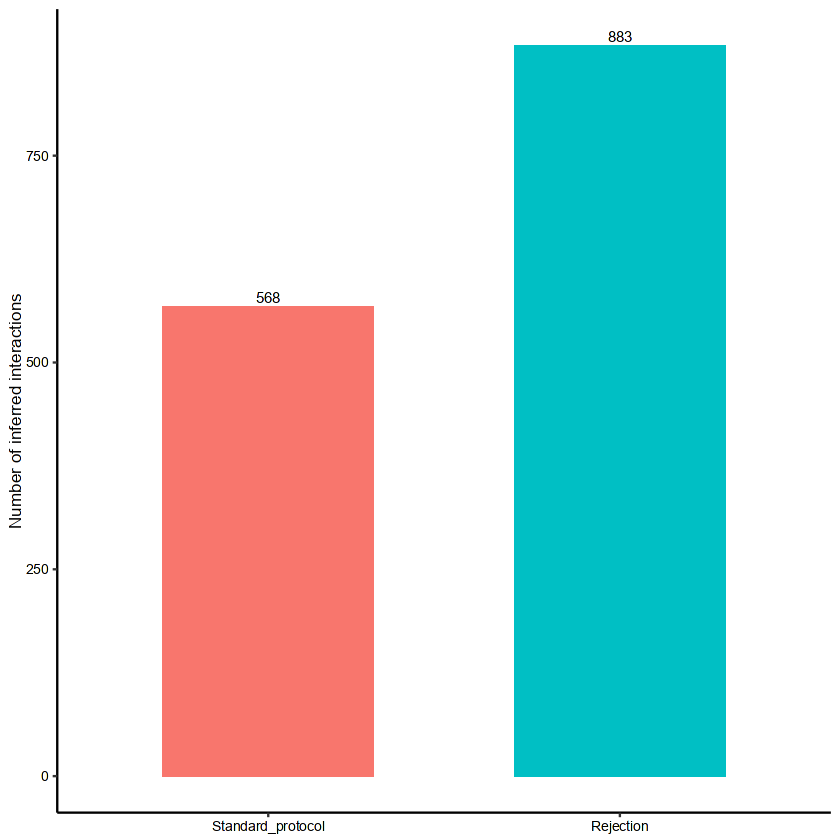

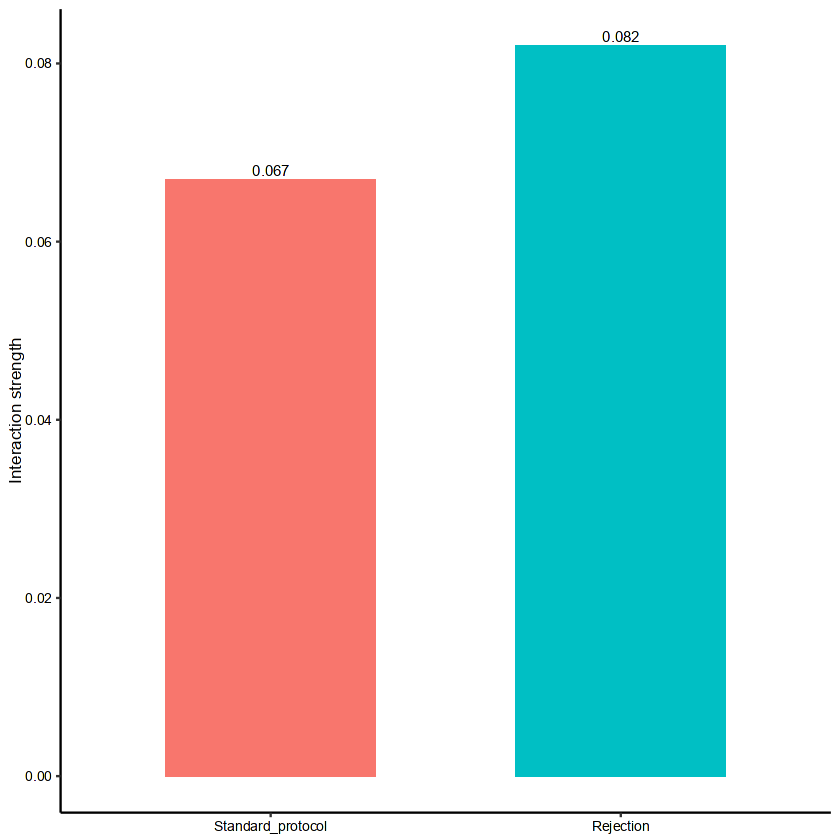

In [22]:
# Read the CSV for downstream use
dif_table <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/Diff_signal_table_ALL_sources_rej_vs_standard.csv", header = TRUE)
signal_path <- unique(dif_table$name)

# 2. Compare total number of interactions and strength
gg1 <- compareInteractions(cellchat_merged, show.legend = FALSE, group = c(1,2))

gg2 <- compareInteractions(cellchat_merged, show.legend = FALSE, group = c(1,2), measure = "weight")
print(gg1)
print(gg2)


In [23]:
# Assuming 'cellchat_merged', 'gg1', and 'gg2' are available in your environment.
library(ggplot2) # Needed for ggsave

# Define the output directory (based on your previous path structure)
output_dir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/Typical_cellchat_rej/"

# Optional: Create the directory if it doesn't exist
if (!dir.exists(output_dir)) {
  dir.create(output_dir, recursive = TRUE)
}

## Save gg1: Comparison of Interaction Numbers
ggsave(filename = paste0(output_dir, "Compare_Interaction_Number_Standard_vs_Rejection.pdf"),
       plot = gg1,
       device = "pdf",
       width = 6, height = 3.5, units = "in", # Standard size (adjust if needed)
       dpi = 300)

## Save gg2: Comparison of Interaction Weights/Strengths
ggsave(filename = paste0(output_dir, "Compare_Interaction_Weight_Standard_vs_Rejection.pdf"),
       plot = gg2,
       device = "pdf",
       width = 6, height = 3.5, units = "in", # Standard size (adjust if needed)
       dpi = 300)

cat("Successfully saved 'Compare_Interaction_Number_Standard_vs_Rejection.pdf' and 'Compare_Interaction_Weight_Standard_vs_Rejection.pdf' to the output directory at 300 dpi.\n")

Successfully saved 'Compare_Interaction_Number_Standard_vs_Rejection.pdf' and 'Compare_Interaction_Weight_Standard_vs_Rejection.pdf' to the output directory at 300 dpi.


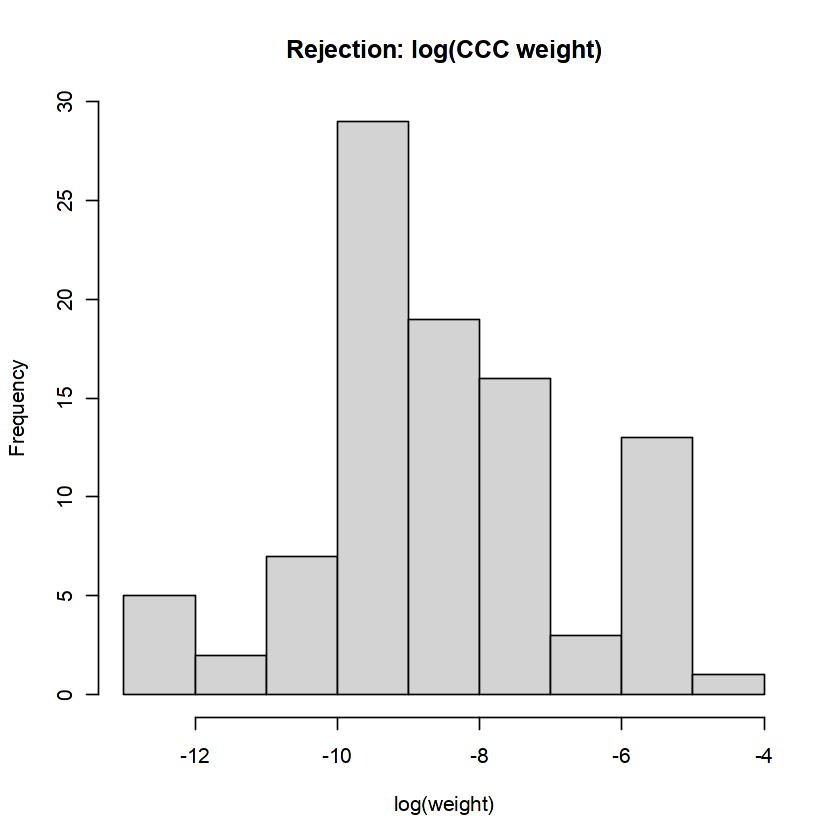

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


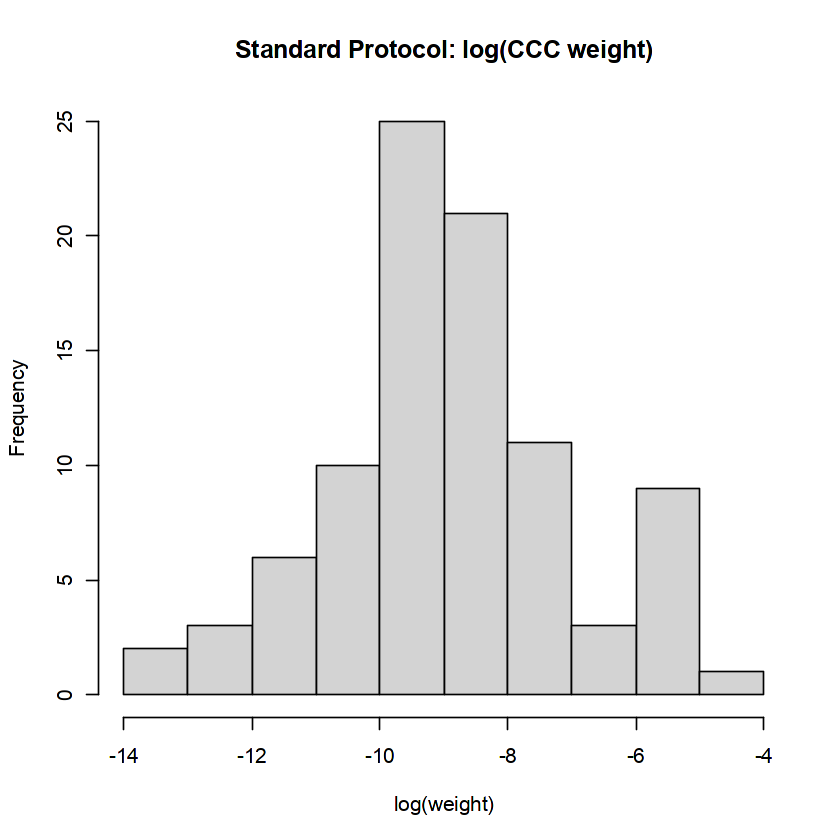

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


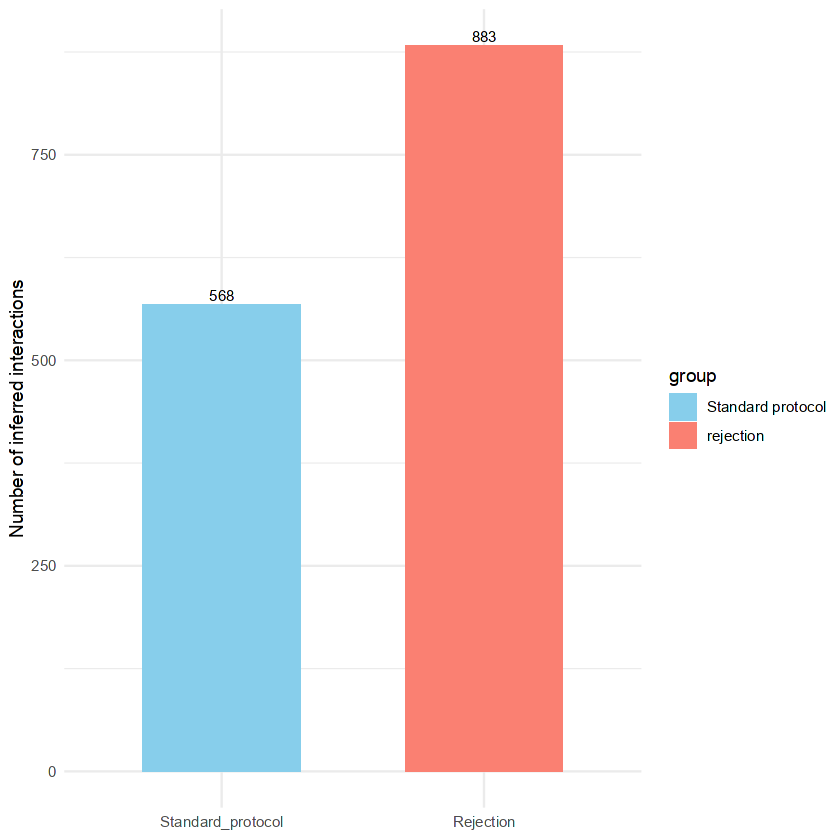

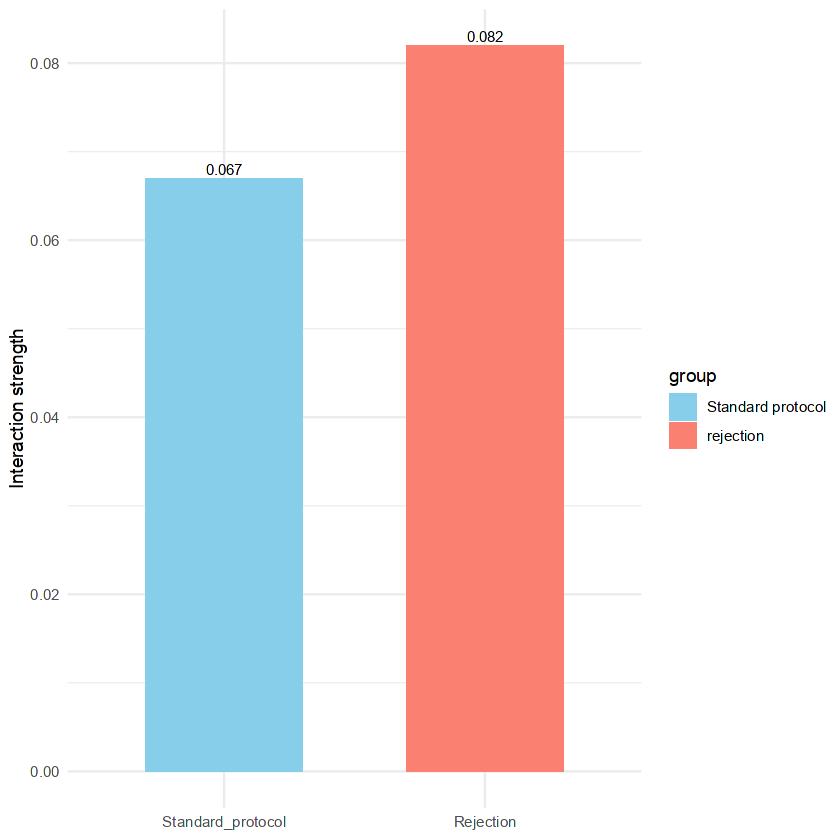

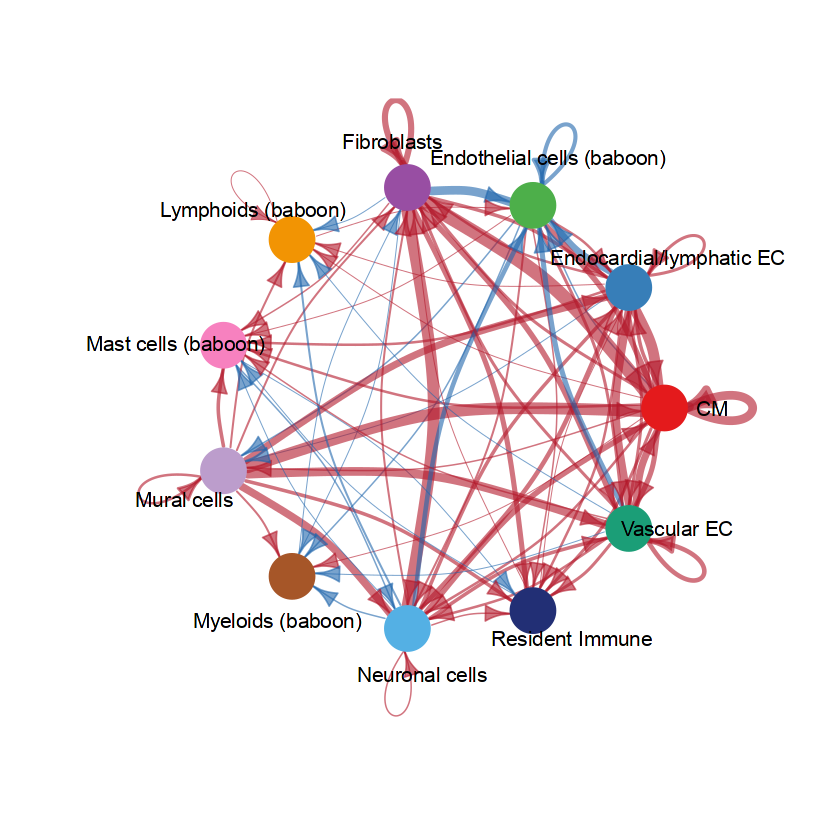

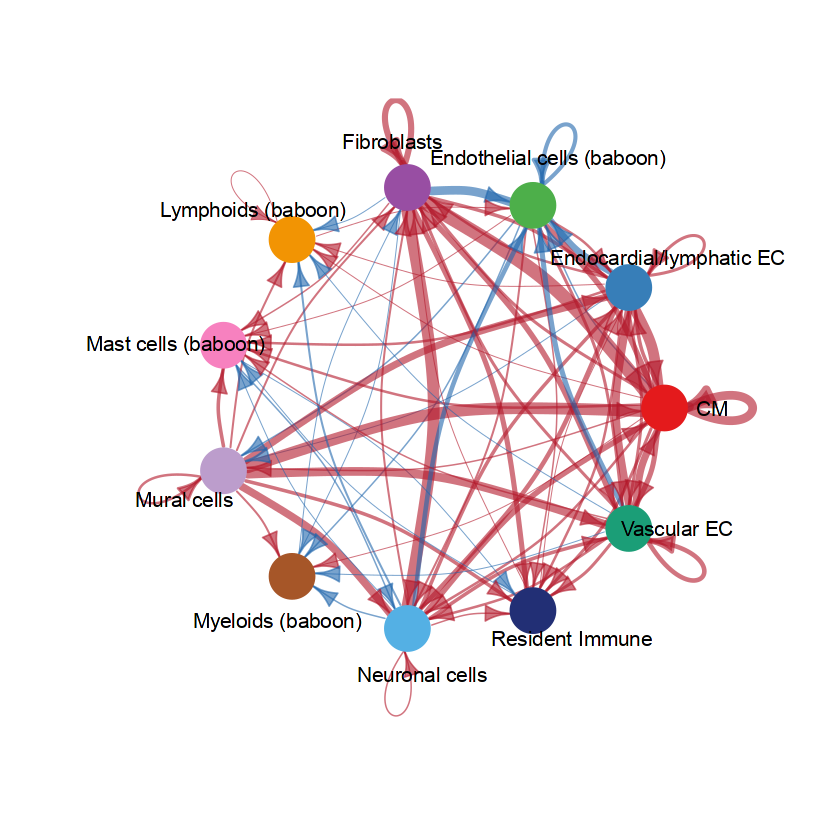

In [24]:
# 3. Plot CCC probability distributions (histograms)
hist(log(cellchat_rej@net$weight), main="Rejection: log(CCC weight)", xlab="log(weight)")
hist(log(cellchat_standard@net$weight), main="Standard Protocol: log(CCC weight)", xlab="log(weight)")
library(ggplot2)

# Define fill color vector for as many bars as you have; here, first two special, others grey
cols1 <- c("skyblue", "salmon", rep("grey", nrow(ggplot_build(gg1)$data[[1]]) - 2))
cols2 <- c("skyblue", "salmon", rep("grey", nrow(ggplot_build(gg2)$data[[1]]) - 2))

# Specify which fill values/levels correspond to your groups
# Adjust breaks as needed if group levels differ (e.g., numeric vs character)
gg1 +
  scale_fill_manual(
    values = cols1,
    breaks = c("1", "2"),
    labels = c("Standard protocol", "rejection")
  ) +
  theme_minimal()

gg2 +
  scale_fill_manual(
    values = cols2,
    breaks = c("1", "2"),
    labels = c("Standard protocol", "rejection")
  ) +
  theme_minimal()
netVisual_diffInteraction(
  cellchat_merged, 
  weight.scale = TRUE,
  # color.use = c("blue", "red"),   # blue=PerProtocol, red=Rejection
  arrow.size = 1
)


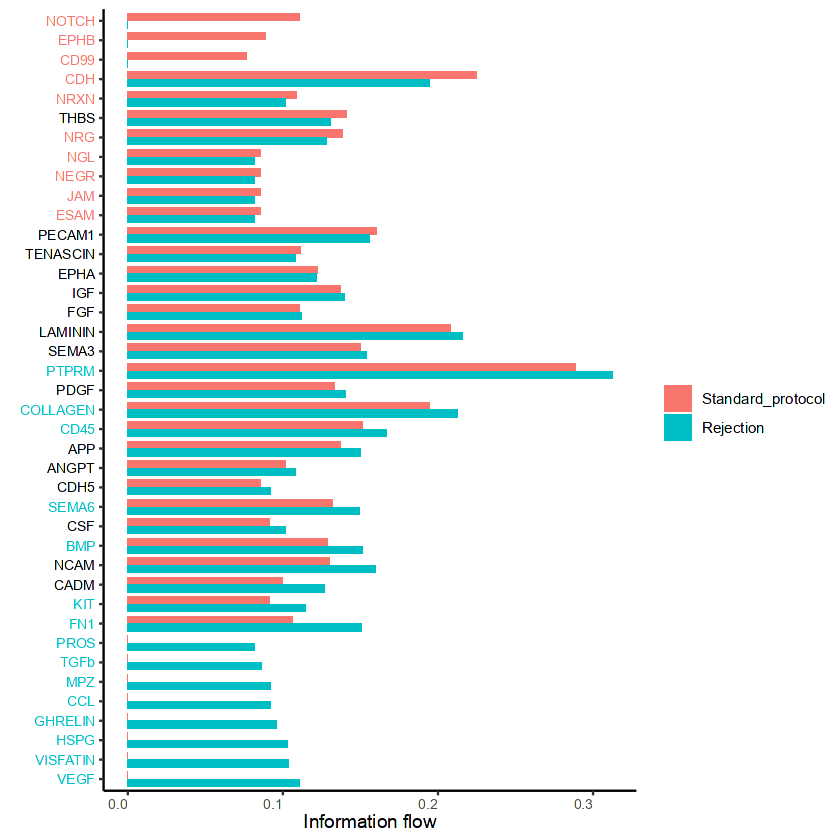

In [25]:
# Rank signaling pathways by differences in overall communication strength
rankNet(cellchat_merged, mode = "comparison", stacked = FALSE, do.stat = TRUE)


Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


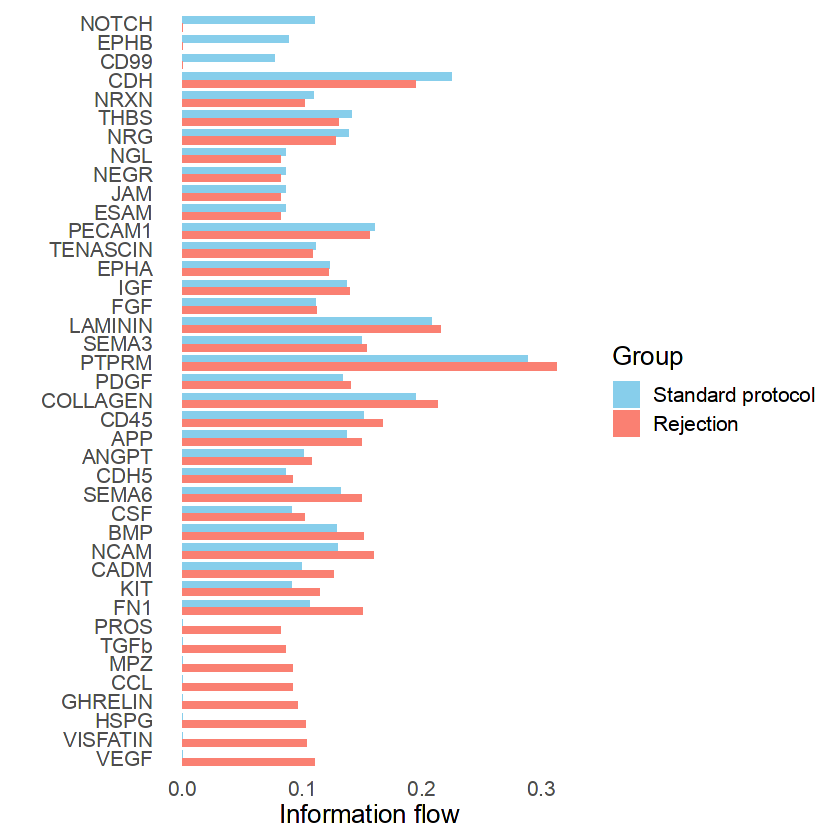

In [26]:
# Get the ggplot object
g <- rankNet(cellchat_merged, mode = "comparison", stacked = FALSE, do.stat = TRUE)

# Add custom colors and remove grids
g + scale_fill_manual(
      values = c("Standard_protocol" = "skyblue", "Rejection" = "salmon"),
      name = "Group",
      labels = c("Rejection", "Standard protocol")
    ) +
    theme_minimal(base_size = 15) +
    theme(
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank()
    )


In [33]:
library(ggplot2)

# Run rankNet in comparison mode (returns a ggplot object)
p_rank <- rankNet(
  cellchat_merged,
  mode    = "comparison",
  stacked = FALSE,
  do.stat = TRUE
)

# Re-map colors
p_rank <- p_rank +
  scale_fill_manual(values = c("Standard_protocol" = "skyblue",
                               "Rejection"         = "salmon")) +
  labs(fill = "Group") +
  theme_bw(base_size = 7) +
  theme(
    legend.position = "top",
    panel.grid.minor = element_blank()
  )

# Save as high-quality vector PDF
out_dir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/Typical_cellchat_rej"
if (!dir.exists(out_dir)) dir.create(out_dir, recursive = TRUE)

out_pdf <- file.path(out_dir, "RankNet_comparison_Standard_vs_Rejection.pdf")

ggsave(
  filename = out_pdf,
  plot     = p_rank,
  width    = 2.25,
  height   = 3.6,
  units    = "in",
  device   = cairo_pdf  # use cairo for embedded fonts
)

message("Saved: ", out_pdf)


Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/Typical_cellchat_rej/RankNet_comparison_Standard_vs_Rejection.pdf



In [37]:
library(ggplot2)
# Ensure 'extrafont' is loaded if 'Arial' is not a default font in your R environment
# library(extrafont) 
# loadfonts(device = "pdf")

# Run rankNet in comparison mode (returns a ggplot object)
p_rank <- rankNet(
  cellchat_merged,
  mode    = "comparison",
  stacked = FALSE,
  do.stat = TRUE
)

# Re-map colors
p_rank <- p_rank +
  scale_fill_manual(values = c("Standard_protocol" = "skyblue",
                               "Rejection"         = "salmon")) +
  labs(fill = "Group") +
  # --- MODIFICATION: Apply Arial font and size 7 ---
  theme_bw() + # Start with theme_bw for a clean base
  theme(
    # Set the global font to Arial and size 7
    text = element_text(family = "Arial", size = 5),
    
    # Ensure specific elements like axis titles/text also use size 7
    axis.title = element_text(family = "Arial", size = 7),
    axis.text = element_text(family = "Arial", size = 7),
    legend.text = element_text(family = "Arial", size = 7),
    legend.title = element_text(family = "Arial", size = 7, face = "bold"),
    
    legend.position = "top",
    
    # --- CRITICAL MODIFICATION: Remove ALL internal grid lines ---
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank()
    # -----------------------------------------------------------
  )
# --------------------------------------------------

# Save as high-quality vector PDF
out_dir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/Typical_cellchat_rej"
if (!dir.exists(out_dir)) dir.create(out_dir, recursive = TRUE)

out_pdf <- file.path(out_dir, "RankNet_comparison_Standard_vs_Rejection_Arial7_NoGrid.pdf")

ggsave(
  filename = out_pdf,
  plot     = p_rank,
  width    = 2.5,
  height   = 4.75,
  units    = "in",
  # --- MODIFICATION: Set dpi to 350 ---
  dpi      = 350,
  # ------------------------------------
  device   = cairo_pdf # use cairo for robust font embedding
)

message("Saved: ", out_pdf)

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/Typical_cellchat_rej/RankNet_comparison_Standard_vs_Rejection_Arial7_NoGrid.pdf



Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


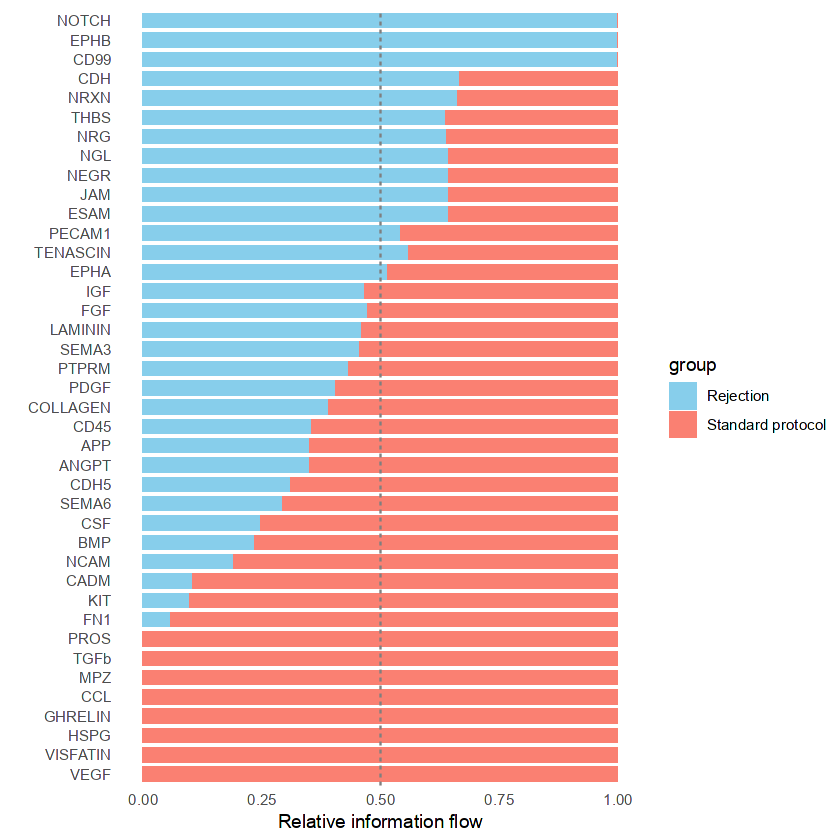

In [27]:
# Re-run rankNet with stacked = TRUE to get the appropriate plot structure
p_ranknet_stacked <- rankNet(
  cellchat_merged,
  mode = "comparison",
  stacked = TRUE, # <--- Change this
  do.stat = TRUE
)

# Apply your custom colors—this should now work
p_ranknet_stacked +
  scale_fill_manual(
    values = c("Standard_protocol" = "skyblue",
               "Rejection" = "Salmon"),
    # Fix labels to match the legend order if needed, but the values mapping is key
    labels = c("Standard protocol", "Rejection") # Assuming this is the order in the legend
  ) +
  theme_minimal() +
  theme(
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank()
  )

In [29]:
library(CellChat)
library(dplyr)
library(tidyr)

# Define the signaling pathway of interest
pathway_name <- "NOTCH"

# List to store the extracted results for both conditions
expression_results <- list()

# Loop through the two CellChat objects
for (name in names(object.list)) {
  cc_obj <- object.list[[name]]

  # 1. Extract the significant ligand-receptor pairs and their associated genes for NOTCH
  # geneLR.return = TRUE returns a list with the L-R pair table and the gene names
  notch_lr_info <- extractEnrichedLR(
    cc_obj,
    signaling = pathway_name,
    geneLR.return = TRUE,
    enriched.only = TRUE # Only return L-R pairs that are significant
  )
  
  # Check if any significant L-R pairs were found
  if (is.null(notch_lr_info$lr.show)) {
    message(paste0("No significant L-R pairs found for ", pathway_name, " in ", name, "."))
    next
  }

  # The second element contains the unique gene names (ligands and receptors)
  notch_genes <- notch_lr_info$gene.show 
  
  # 2. Compute the average expression for these specific NOTCH genes across all cell groups
  # The 'features' argument takes a vector of gene names
  # 'type = "truncatedMean"' is CellChat's default robust mean
  notch_expr_data <- computeAveExpr(
    cc_obj, 
    features = notch_genes, 
    type = "truncatedMean"
  )
  
  # 3. Convert the expression matrix to a data frame for easier viewing/saving
  # Extract the average expression matrix
  expr_matrix <- as.data.frame(notch_expr_data$avg)
  
  # Add gene names as a column and pivot to long format
  expr_df_long <- expr_matrix %>%
    tibble::rownames_to_column("Gene") %>%
    pivot_longer(
      cols = -Gene,
      names_to = "Cell_Type",
      values_to = "Avg_Expression"
    ) %>%
    mutate(
      Condition = name,
      Pathway = pathway_name
    )
  
  # Store the result
  expression_results[[name]] <- expr_df_long
  
  message(paste0("Extracted NOTCH expression data for ", name, "."))
}

# Combine results into a single data frame
combined_notch_expression_df <- bind_rows(expression_results)

# Display the first few rows of the combined data
print(head(combined_notch_expression_df))

# --- OPTIONAL: Save the combined expression data to a CSV file ---

# Define the output directory (based on your previous path structure)
output_dir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/"
output_file <- file.path(output_dir, "NOTCH_LR_Avg_Expression_Standard_vs_Rejection.csv")

# Create directory if it doesn't exist
if (!dir.exists(output_dir)) {
  dir.create(output_dir, recursive = TRUE)
}

write.csv(
  combined_notch_expression_df,
  file = output_file,
  row.names = FALSE
)

message(paste0("Saved combined NOTCH average expression data to: ", output_file))

# --- OPTIONAL: Visualize the expression using a dot plot ---

# You can use the built-in 'plotGeneExpression' function on the CellChat object 
# for a simple visualization, or use ggplot with the combined_notch_expression_df.

# Example visualization for NOTCH pathway genes in 'cellchat_standard'
# You would need the original expression data for this, but 'plotGeneExpression' 
# can work on the 'CellChat' object if the raw or normalized data is in the 'data' slot.

# Visualizing the key NOTCH genes identified above (assuming they were found)
if (exists("notch_genes") && length(notch_genes) > 0) {
    p_expr_rej <- plotGeneExpression(cellchat_rej, features = notch_genes)
    print(p_expr_rej)
    
    p_expr_standard <- plotGeneExpression(cellchat_standard, features = notch_genes)
    print(p_expr_standard)
    
    # You can also use the combined_notch_expression_df with ggplot2 for a combined plot
    # Not including the full ggplot code here for brevity, but it's a standard dotplot/heatmap.
} else {
    message("No significant NOTCH L-R pairs were found to plot gene expression.")
}

No significant L-R pairs found for NOTCH in Standard_protocol.

There is no significant communication of NOTCH

No significant L-R pairs found for NOTCH in Rejection.



# A tibble: 0 × 0


Saved combined NOTCH average expression data to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results//NOTCH_LR_Avg_Expression_Standard_vs_Rejection.csv

No significant NOTCH L-R pairs were found to plot gene expression.



Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


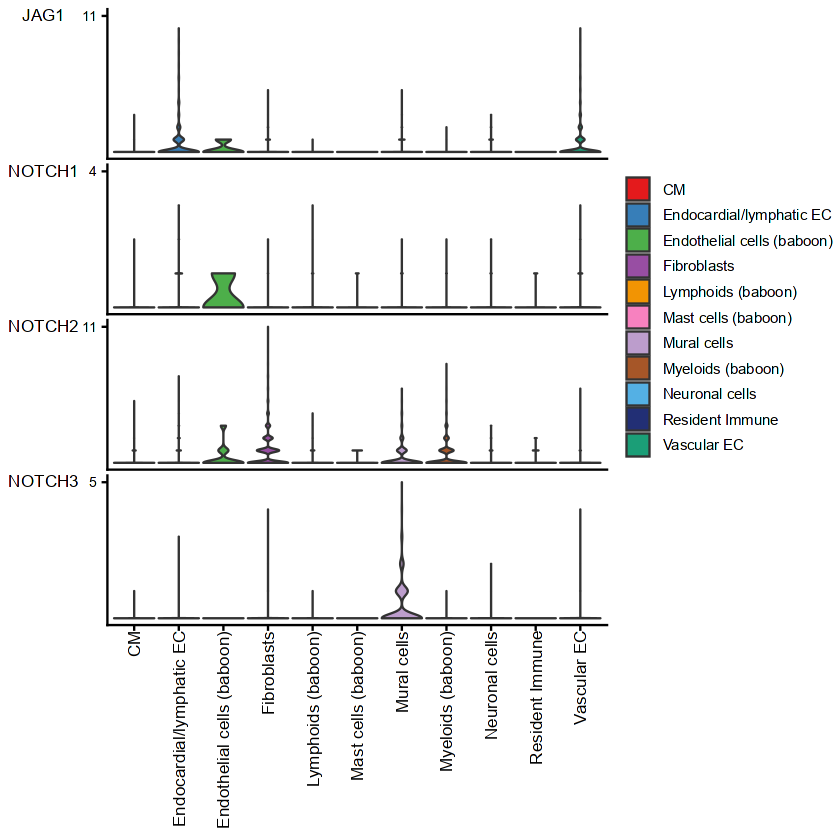

In [36]:
# 1. Inspect the remaining pathways in the Standard protocol
# pathways_to_check_std <- c("VISFATIN")
# object_to_check_std <- cellchat_extended

# for (pw in pathways_to_check_std) {
#     p <- CellChat::plotGeneExpression(
#         object_to_check_std, 
#         signaling = pw 
#     ) + ggplot2::ggtitle(paste("Standard Protocol: L-R Gene Expression for", pw))
#     if (inherits(p, "ggplot")) { print(p) }
# }

# 2. Inspect the same pathways in the Extended protocol (where they were found)
pathways_to_check_ext <- c("NOTCH")
object_to_check_ext <- cellchat_standard

for (pw in pathways_to_check_ext) {
    p <- CellChat::plotGeneExpression(
        object_to_check_ext, 
        signaling = pw 
    ) + ggplot2::ggtitle(paste("standard Protocol: L-R Gene Expression for", pw))
    if (inherits(p, "ggplot")) { print(p) }
}

In [38]:
library(CellChat)
library(ggplot2)
library(dplyr)
library(tidyr)

# --- 1. Data Extraction ---
# Assuming 'object.list' contains: list(Standard_protocol = cellchat_standard, Rejection = cellchat_rej)

# Cell type of interest
cell_oi <- "Fibroblasts"

# Initialize a list to hold the extracted data
data_list <- list()

# Loop through the two conditions (Standard and Rejection)
for (name in names(object.list)) {
  cc_obj <- object.list[[name]]
  
  # Get the total number of outgoing links (Sender) from Fibroblasts
  # Use net@count to get the number of interactions
  sender_count <- sum(cc_obj@net$count[cell_oi, ])
  
  # Get the total number of incoming links (Receiver) to Fibroblasts
  receiver_count <- sum(cc_obj@net$count[, cell_oi])
  
  # Store results
  data_list[[name]] <- data.frame(
    Condition = name,
    Role = c("Sender", "Receiver"),
    Count = c(sender_count, receiver_count)
  )
}

# Combine the data into a single data frame
plot_data_fibroblasts <- bind_rows(data_list)

# --- 2. Plot Generation (Grouped Bar Plot) ---

# Define output path and colors
out_dir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/Typical_cellchat_rej"
out_pdf <- file.path(out_dir, "Fibroblasts_Sender_Receiver_Comparison.pdf")

# Define the custom theme (Arial 7pt, no grid)
custom_theme <- theme_bw() +
  theme(
    text = element_text(family = "Arial", size = 7),
    axis.title = element_text(family = "Arial", size = 7),
    axis.text = element_text(family = "Arial", size = 7),
    legend.text = element_text(family = "Arial", size = 7),
    legend.title = element_text(family = "Arial", size = 7, face = "bold"),
    legend.position = "top",
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank()
  )

# Create the Grouped Bar Plot
p_fibro_role <- ggplot(plot_data_fibroblasts, aes(x = Role, y = Count, fill = Condition)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.8), width = 0.7) +
  geom_text(
    aes(label = Count), 
    position = position_dodge(width = 0.8), 
    vjust = -0.5, 
    size = 2.5,
    family = "Arial"
  ) +
  scale_fill_manual(
    values = c("Standard_protocol" = "skyblue", "Rejection" = "salmon"),
    labels = c("Rejection", "Standard Protocol")
  ) +
  labs(
    title = "Fibroblasts: Total Intercellular Communication Role",
    y = "Number of Interactions (All Pathways)",
    x = "Communication Role"
  ) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.15))) + # Expand y-axis for labels
  custom_theme

# --- 3. Save Plot at 350 DPI ---
if (!dir.exists(out_dir)) dir.create(out_dir, recursive = TRUE)

ggsave(
  filename = out_pdf,
  plot     = p_fibro_role,
  width    = 3.5,
  height   = 4.5,
  units    = "in",
  dpi      = 350,
  device   = cairo_pdf
)

message("Saved comparative Fibroblast role plot: ", out_pdf)

Saved comparative Fibroblast role plot: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/Typical_cellchat_rej/Fibroblasts_Sender_Receiver_Comparison.pdf



In [6]:
library(CellChat)
library(ggplot2)
library(pheatmap) # The standard library CellChat uses for heatmaps
if (!is.null(dev.list())) dev.off() # Ensure existing plot devices are closed

# --- 1. Data Extraction and Preparation ---

# Cell type of interest
cell_oi <- "Fibroblasts"
conditions <- names(object.list)

# Initialize a list to store the filtered count matrices
fibro_matrices <- list()

# Define output path
out_dir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/Typical_cellchat_rej"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)
out_pdf <- file.path(out_dir, "Fibroblasts_Cell_Cell_Count_Ordered_Heatmap.pdf") # Updated filename

# --- DEFINE DESIRED CELL ORDER ---
cell_order_display <- c(
    "CM", "Fibroblasts", "Vascular ECs", "Mural cells", "Neuronal cells",
    "Endocardial/lymphatic EC", "Resident Immune", "Myeloids (baboon)",
    "Lymphoids (baboon)", "Endothelial cells (baboon)", "Mast cells (baboon)"
)
# --- END DEFINE DESIRED CELL ORDER ---

# Loop through conditions to extract and filter the interaction count matrix (net@count)
for (cond in conditions) {
    cc_obj <- object.list[[cond]]
    
    # Get the full interaction count matrix
    full_count_matrix <- cc_obj@net$count
    
    # Rows/Columns to keep: all other cell types plus Fibroblasts itself
    all_cells <- unique(c(rownames(full_count_matrix), colnames(full_count_matrix)))
    
    # Identify all partners (excluding Fibroblasts from the partner list)
    partners <- setdiff(all_cells, cell_oi)
    
    # Create a comparative data frame for this condition
    df_comp <- data.frame(
        'Source' = all_cells, 
        'Target' = all_cells, 
        'Fibro_as_Sender' = full_count_matrix[cell_oi, all_cells], 
        'Fibro_as_Receiver' = full_count_matrix[all_cells, cell_oi] 
    ) %>%
        # Remove self-loops where Fibroblasts is both sender and receiver
        filter(Source != cell_oi) %>%
        # Keep only the columns needed for plotting
        select(Source, Fibro_as_Sender, Fibro_as_Receiver)
    
    # Convert back to matrices for heatmap (where rows are cell types)
    # The row names are the partner cells (Source)
    sender_mat <- matrix(df_comp$Fibro_as_Sender, ncol = 1, dimnames = list(df_comp$Source, paste0(cond, "_Sent")))
    receiver_mat <- matrix(df_comp$Fibro_as_Receiver, ncol = 1, dimnames = list(df_comp$Source, paste0(cond, "_Received")))
    
    # Combine the sender and receiver roles for each condition
    fibro_matrices[[cond]] <- cbind(receiver_mat, sender_mat)
}

# Final combined matrix for plotting (Rows = Cell Types, Columns = 4 roles)
final_mat_raw <- cbind(fibro_matrices[['Standard_protocol']], fibro_matrices[['Rejection']])
colnames(final_mat_raw) <- c("Received (standard)", "Sent (standard)", "Received (Rejection)", "Sent (Rejection)")

# --- MODIFICATION: Apply the specified cell order to the matrix rows ---

# 1. Filter the desired order to only include cell types present in the final_mat
valid_order_partners <- intersect(setdiff(cell_order_display, cell_oi), rownames(final_mat_raw))

# 2. Reorder the matrix
final_mat <- final_mat_raw[valid_order_partners, ]

# --- 2. Heatmap Visualization using pheatmap ---

# Define the annotation (Groups)
annotation_col <- data.frame(
    Condition = factor(c("Standard", "Standard", "Rejection", "Rejection")),
    Role = factor(c("Received by FBs", "Sent by FBs", "Received by FBs", "Sent by FBs"), levels = c("Received by FBs", "Sent by FBs"))
)
rownames(annotation_col) <- colnames(final_mat)

# Define custom colors for the columns/roles
ann_colors = list(
    Condition = c(Standard = "skyblue", Rejection = "salmon"),
    Role = c("Received by FBs" = "grey90", "Sent by FBs" = "grey40") # Roles as neutral shades
)

# Open PDF device with 350 dpi
pdf(file = out_pdf, width = 5, height = 6) # Adjusted size for better visibility

pheatmap(
    final_mat,
    cluster_rows = FALSE, # <--- KEY CHANGE: DISABLE CLUSTERING TO MAINTAIN ORDER
    cluster_cols = FALSE, # Do not cluster the roles (keep them grouped by condition/role)
    display_numbers = TRUE,
    number_color = "black",
    fontsize = 7, # Increased fontsize for clarity
    color = colorRampPalette(c("white", "orange", "red"))(100), # Original color scheme
    main = paste0("Comparative Pathway Counts IN/OUT of ", cell_oi),
    annotation_col = annotation_col,
    annotation_colors = ann_colors,
    # The legend_labels argument from the original code causes the error you fixed before, 
    # so we omit it here as it conflicts with pheatmap's default legend behavior.
    # The default legend shows the numeric range.
)

dev.off()
message("Saved comparative Fibroblast interaction count heatmap with custom order: ", out_pdf)

null device 
          1

pdf 
  3

Saved comparative Fibroblast interaction count heatmap with custom order: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/Typical_cellchat_rej/Fibroblasts_Cell_Cell_Count_Ordered_Heatmap.pdf



# Horizontal FB-input output heatmap

In [82]:
# library(CellChat)
# library(ggplot2)
# library(pheatmap)
# if (!is.null(dev.list())) dev.off()

# # --- 1. Data Extraction and Preparation ---

# # Cell type of interest
# cell_oi <- "Fibroblasts"
# conditions <- names(object.list)

# # Initialize a list to store the filtered count matrices
# fibro_matrices <- list()

# # Define output path
# out_dir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/Typical_cellchat_rej"
# dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)
# out_pdf <- file.path(out_dir, "Fibroblasts_Cell_Cell_Count_Rotated_Clustered_Heatmap.pdf") # Updated filename

# # --- DEFINE DESIRED CELL ORDER (USED FOR FILTERING/INITIAL MATRIX, BUT OVERRIDDEN BY CLUSTERING) ---
# cell_order_display <- c(
#     "CM", "Fibroblasts", "Vascular ECs", "Mural cells", "Neuronal cells",
#     "Endocardial/lymphatic EC", "Resident Immune", "Myeloids (baboon)",
#     "Lymphoids (baboon)", "Endothelial cells (baboon)", "Mast cells (baboon)"
# )

# # Loop through conditions to extract and prepare the count matrix
# for (cond in conditions) {
#     cc_obj <- object.list[[cond]]
#     full_count_matrix <- cc_obj@net$count
#     all_cells <- unique(c(rownames(full_count_matrix), colnames(full_count_matrix)))
#     partners <- setdiff(all_cells, cell_oi)
    
#     df_comp <- data.frame(
#         'Source' = all_cells, 
#         'Target' = all_cells, 
#         'Fibro_as_Sender' = full_count_matrix[cell_oi, all_cells], 
#         'Fibro_as_Receiver' = full_count_matrix[all_cells, cell_oi] 
#     ) %>%
#         filter(Source != cell_oi) %>%
#         select(Source, Fibro_as_Sender, Fibro_as_Receiver)
    
#     # Rows: Partner Cell Types (Source), Columns: Role
#     sender_mat <- matrix(df_comp$Fibro_as_Sender, ncol = 1, dimnames = list(df_comp$Source, paste0(cond, "_Sent")))
#     receiver_mat <- matrix(df_comp$Fibro_as_Receiver, ncol = 1, dimnames = list(df_comp$Source, paste0(cond, "_Received")))
    
#     fibro_matrices[[cond]] <- cbind(receiver_mat, sender_mat)
# }

# # Final combined matrix (Rows: Partners, Columns: 4 Roles)
# final_mat_raw <- cbind(fibro_matrices[['Standard_protocol']], fibro_matrices[['Rejection']])
# colnames(final_mat_raw) <- c("Received (standard)", "Sent (standard)", "Received (Rejection)", "Sent (Rejection)")

# # 1. Filter and reorder the rows (partners) based on the display order
# valid_order_partners <- intersect(setdiff(cell_order_display, cell_oi), rownames(final_mat_raw))
# ordered_mat <- final_mat_raw[valid_order_partners, ]

# # --- TRANSPOSE THE MATRIX (Rotate 90 degrees) ---
# # Rows = 4 Roles/Conditions, Columns = Partner Cell Types
# rotated_mat <- t(ordered_mat)
# # --- END TRANSPOSE ---

# # --- 2. Heatmap Visualization using pheatmap ---

# # --- ANNOTATION ADJUSTMENT ---
# # Annotation applies to ROWS (the 4 Roles/Conditions)
# annotation_row <- data.frame(
#     Condition = factor(c("Standard", "Standard", "Rejection", "Rejection")),
#     Role = factor(
#         c("Received by Fibroblasts.", "Sent by Fibroblasts.", "Received by Fibroblasts.", "Sent by Fibroblasts."), 
#         levels = c("Received by Fibroblasts.", "Sent by Fibroblasts.")
#     )
# )
# rownames(annotation_row) <- rownames(rotated_mat)

# # Define custom colors for the rows (formerly columns)
# ann_colors = list(
#     Condition = c(Standard = "skyblue", Rejection = "salmon"),
#     Role = c("Received by Fibroblasts." = "grey90", "Sent by Fibroblasts." = "grey40")
# )
# # --- END ANNOTATION ADJUSTMENT ---

# # Open PDF device
# pdf(file = out_pdf, width = 9.2, height = 2.2) 

# pheatmap(
#     rotated_mat,
#     cluster_rows = FALSE, # <--- DO NOT CLUSTER CONDITIONS/ROLES (Rows)
#     cluster_cols = FALSE,  # <--- CLUSTER CELL TYPES (Columns)
#     display_numbers = TRUE,
#     number_color = "black",
#     fontsize = 6,
#     angle_col = 0, 
#     color = colorRampPalette(c("white", "orange", "red"))(100), 
#     main = paste0(" "),
#     annotation_row = annotation_row,
#     annotation_colors = ann_colors,
#     # Remove legend_labels to avoid conflict
# )

# dev.off()
# message("Saved rotated, cell-type clustered Fibroblast interaction count heatmap: ", out_pdf)

pdf 
  3

pdf 
  3

Saved rotated, cell-type clustered Fibroblast interaction count heatmap: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/Typical_cellchat_rej/Fibroblasts_Cell_Cell_Count_Rotated_Clustered_Heatmap.pdf



In [9]:
library(dplyr)
library(tidyr)

# Run rankNet with unstacked (group-level) results
ranknet_frame <- rankNet(
  cellchat_merged,
  mode = "comparison",
  stacked = FALSE,
  do.stat = TRUE,
  cutoff.pvalue = 1,    # show all
  return.data = TRUE,
  measure = "weight"
)$signaling.contribution

# Save the raw (long) table for transparency
write.csv(ranknet_frame, "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/new/GENERAL_Diff_signal_table_ALL_sources_GROUP_comparison.csv", row.names = FALSE)

# Pivot wider for direct group-by-group pathway comparison
wide_frame <- ranknet_frame %>%
  select(name, contribution, pvalues, group) %>%
  pivot_wider(
    id_cols = name,
    names_from = group,
    values_from = c(contribution, pvalues)
  )

# Write to CSV
write.csv(wide_frame, "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/new/Diff_signal_table_ALL_sources_GROUP_comparison_WIDE.csv", row.names = FALSE)



Attaching package: ‘tidyr’


The following object is masked from ‘package:S4Vectors’:

    expand


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack


The following object is masked from ‘package:igraph’:

    crossing




In [10]:
library(dplyr)
library(readr)

# Load interaction tables
df_standard <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Standard_CCC_info_table.csv")
df_rej <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Rejection_info_table.csv")

# Combine all unique pathways from both conditions
all_pathways <- unique(c(
    as.character(unique(df_standard$pathway_name)),
    as.character(unique(df_rej$pathway_name))
))
all_pathways <- all_pathways[!is.na(all_pathways) & all_pathways != ""]

# Directory to save
outdir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/pathway_specific/"
dir.create(outdir, showWarnings = FALSE)

# Loop through each pathway and save comparison table
for (pw in all_pathways) {
  # Flexible match (case insensitive, handles errors)
  pw_standard <- df_standard %>%
    filter(tolower(pathway_name) == tolower(pw)) %>%
    select(pathway_name, ligand, receptor, source, target, prob, pval) %>%
    mutate(group = "Standard_protocol")
  
  pw_rej <- df_rej %>%
    filter(tolower(pathway_name) == tolower(pw)) %>%
    select(pathway_name, ligand, receptor, source, target, prob, pval) %>%
    mutate(group = "Rejection")
  
  pw_all <- bind_rows(pw_standard, pw_rej) %>%
    arrange(pathway_name, ligand, receptor, source, target, group)
  
  # Only write if at least one row exists
  if (nrow(pw_all) > 0) {
    outfn <- paste0(outdir, gsub("[^A-Za-z0-9]", "_", pw), "_group_comparison.csv")
    write_csv(pw_all, outfn)
  }
}



Attaching package: ‘readr’


The following object is masked from ‘package:scales’:

    col_factor




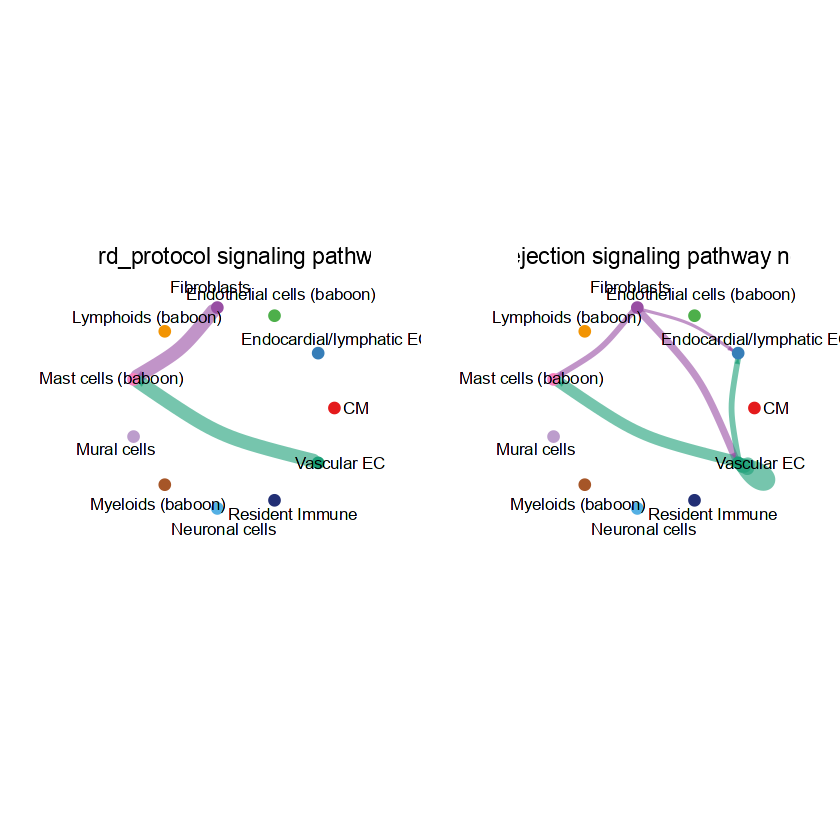

In [11]:
pathway.show <- "KIT"
# Compare both datasets side by side
par(mfrow = c(1,2))
for (i in 1:length(object.list)) {
  netVisual_aggregate(
    object.list[[i]],
    signaling = pathway.show,
    layout = "circle",   # or "hierarchy", "chord"
    signaling.name = paste(pathway.show, names(object.list)[i])
  )
}

In [12]:
cellchat_rej@netP$pathways

[1] "PTPRM"    "LAMININ"  "COLLAGEN" "CDH"      "CD45"     "NCAM"    
 [7] "PECAM1"   "SEMA3"    "BMP"      "FN1"      "APP"      "SEMA6"   
[13] "PDGF"     "IGF"      "THBS"     "NRG"      "CADM"     "EPHA"    
[19] "KIT"      "FGF"      "VEGF"     "TENASCIN" "ANGPT"    "VISFATIN"
[25] "HSPG"     "CSF"      "NRXN"     "GHRELIN"  "CCL"      "CDH5"    
[31] "MPZ"      "TGFb"     "PROS"     "ESAM"     "JAM"      "NEGR"    
[37] "NGL"

In [13]:
cellchat_standard@netP$pathways

[1] "PTPRM"    "CDH"      "LAMININ"  "COLLAGEN" "PECAM1"   "CD45"    
 [7] "SEMA3"    "THBS"     "NRG"      "APP"      "IGF"      "PDGF"    
[13] "SEMA6"    "NCAM"     "BMP"      "EPHA"     "TENASCIN" "FGF"     
[19] "NOTCH"    "NRXN"     "FN1"      "ANGPT"    "CADM"     "CSF"     
[25] "KIT"      "EPHB"     "CDH5"     "ESAM"     "JAM"      "NEGR"    
[31] "NGL"      "CD99"

In [14]:
# Collect all pathways detected in either object
all_pathways <- unique(c(cellchat_rej@netP$pathways, cellchat_standard@netP$pathways))

# Prepare output folder
plot_dir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/ALL_pathways_circleplots"
if (!dir.exists(plot_dir)) dir.create(plot_dir, recursive = TRUE)


# Define objects and panel names
object.list <- list(Standard_protocol = cellchat_standard, Rejection = cellchat_rej)
panel_titles <- names(object.list)


# ------------------------------------------------------

for (pathway.show in all_pathways) {
  pdf_file <- file.path(plot_dir, paste0(gsub("[/ ]", "_", pathway.show), "_circle_comparison.pdf"))
  pdf(pdf_file, width = 14, height = 7)
  par(mfrow = c(1,2))
  for (i in seq_along(object.list)) {
    obj <- object.list[[i]]
    # Plot only if pathway is present
    if (pathway.show %in% obj@netP$pathways) {
      netVisual_aggregate(
        obj,
        signaling = pathway.show,
        layout = "circle",
        signaling.name = paste(pathway.show, panel_titles[i]),
        arrow.size = 1,
        remove.isolate = FALSE  # To always show, even if only 1 edge
      )
      title(panel_titles[i], line = 1, cex.main = 2, font.main = 2)
    } else {
      plot.new()
      title(paste(panel_titles[i], "\n(Not detected)"), line = 1, cex.main = 2, font.main = 2)
    }
  }
  dev.off()
  cat("Saved:", pdf_file, "\n")
}



Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/ALL_pathways_circleplots/PTPRM_circle_comparison.pdf 
Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/ALL_pathways_circleplots/LAMININ_circle_comparison.pdf 
Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/ALL_pathways_circleplots/COLLAGEN_circle_comparison.pdf 
Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/ALL_pathways_circleplots/CDH_circle_comparison.pdf 
Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/ALL_pathways_circleplots/CD45_circle_comparison.pdf 
Saved: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/ALL_pathways_circleplots/NCAM_circle_comparison.pd


Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




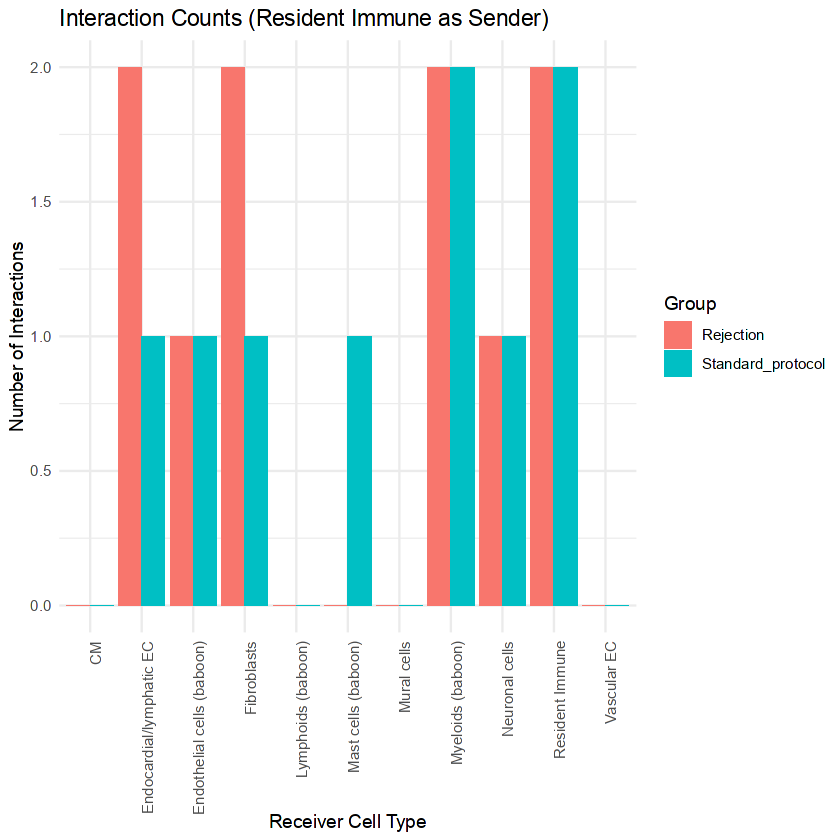

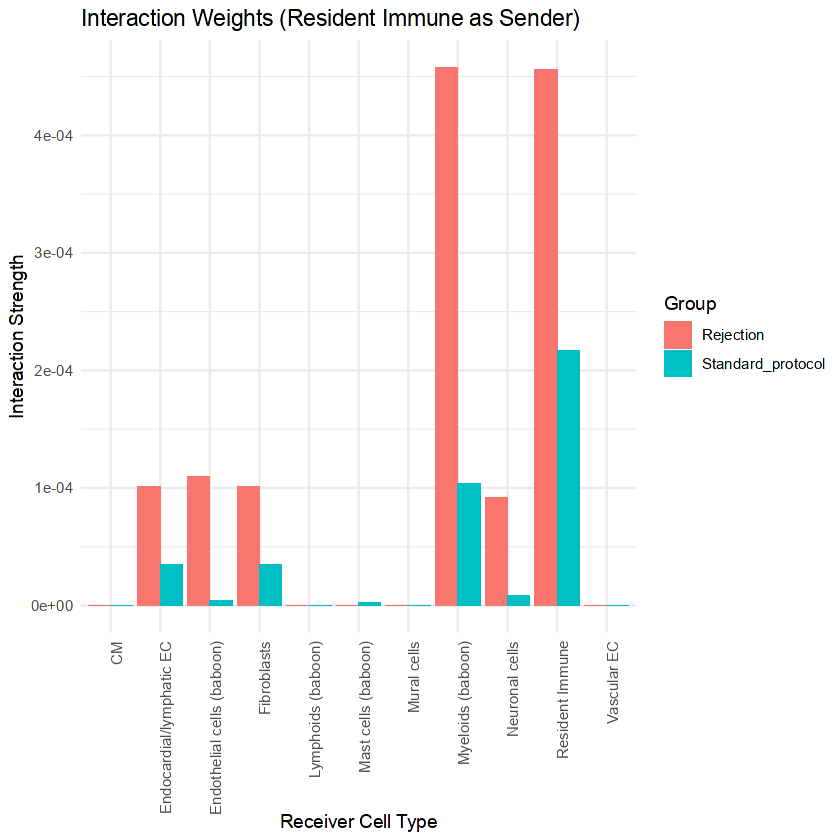

In [15]:
# For Rejection group
rej_interactions <- cellchat_rej@net$count["Resident Immune", ]
rej_interactions_weight <- cellchat_rej@net$weight["Resident Immune", ]

# For Standard protocol group
standard_interactions <- cellchat_standard@net$count["Resident Immune", ]
standard_interactions_weight <- cellchat_standard@net$weight["Resident Immune", ]

# Differential (Rejection - Standard)
diff_count <- rej_interactions - standard_interactions
diff_weight <- rej_interactions_weight - standard_interactions_weight
# Combine data into a data frame for plotting
library(ggplot2)

count_data <- data.frame(
  Receiver = names(rej_interactions),
  Rejection = rej_interactions,
  Standard_protocol = standard_interactions
)

# Melt for ggplot
library(reshape2)
count_melted <- melt(count_data, id.vars = "Receiver", variable.name = "Group", value.name = "Count")

# Plot
ggplot(count_melted, aes(x = Receiver, y = Count, fill = Group)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = "Interaction Counts (Resident Immune as Sender)", x = "Receiver Cell Type", y = "Number of Interactions") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))




# --------------------------------------------------------------------------------------------------------------------------------------------------------------




weight_data <- data.frame(
  Receiver = names(rej_interactions_weight),
  Rejection = rej_interactions_weight,
  Standard_protocol = standard_interactions_weight
)

weight_melted <- melt(weight_data, id.vars = "Receiver", variable.name = "Group", value.name = "Weight")

# Plot
ggplot(weight_melted, aes(x = Receiver, y = Weight, fill = Group)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = "Interaction Weights (Resident Immune as Sender)", x = "Receiver Cell Type", y = "Interaction Strength") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))
# Identify pathways where Resident Immune is a significant sender
pathways_rej <- cellchat_rej@netP$pathways  # All pathways in Rejection
pathways_standard <- cellchat_standard@netP$pathways     # All pathways in Per-Protocol

# Get communication patterns where Resident Immune is a sender
net_rej <- subsetCommunication(cellchat_rej, sources.use = "Resident Immune")
net_standard <- subsetCommunication(cellchat_standard, sources.use = "Resident Immune")

# Find unique pathways involving Resident Immune
resident_pathways_rej <- unique(net_rej$pathway_name)
resident_pathways_standard <- unique(net_standard$pathway_name)

# Combine pathways from both conditions
all_pathways <- union(resident_pathways_rej, resident_pathways_standard)

# Set larger plot margins
par(mar = c(5, 8, 4, 4))  

Comparing communications on a single object 


Comparing communications on a single object 




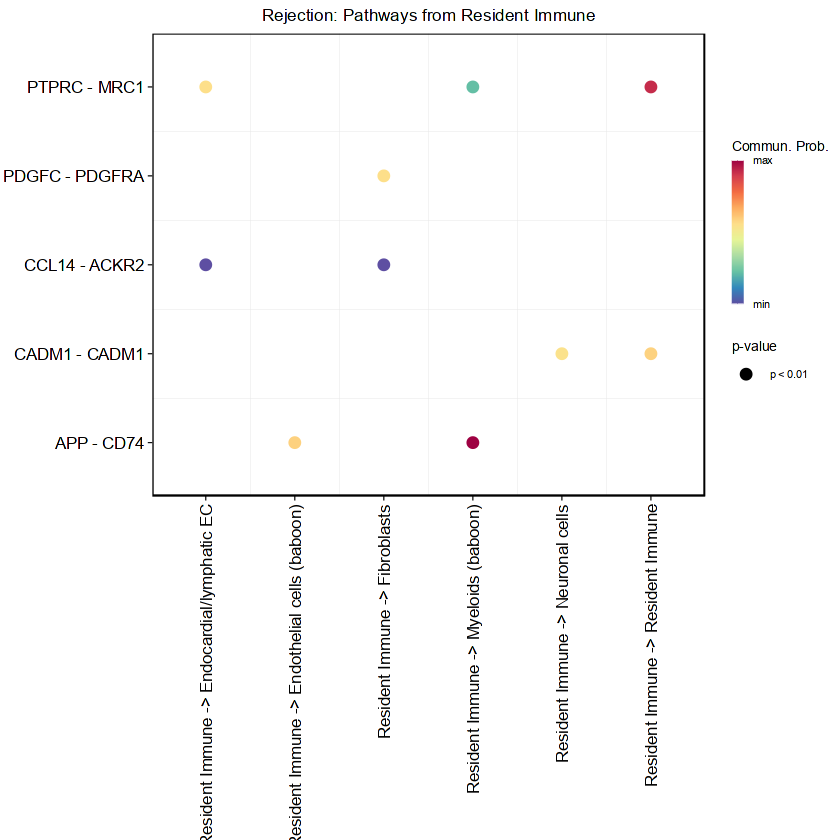

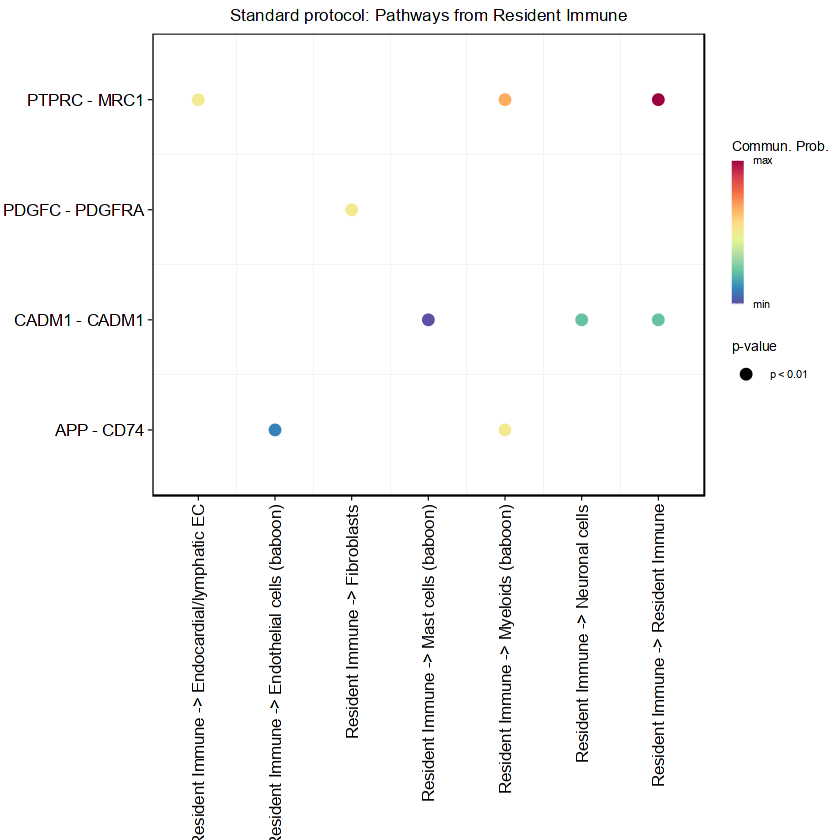

In [16]:
# Rejection group
netVisual_bubble(
  cellchat_rej, 
  sources.use = "Resident Immune", 
  remove.isolate = FALSE,  # Show all pathways, even if weak
  title.name = "Rejection: Pathways from Resident Immune",
  font.size = 12,
  angle.x = 90
)

# Per-Protocol group
netVisual_bubble(
  cellchat_standard, 
  sources.use = "Resident Immune", 
  remove.isolate = FALSE,
  title.name = "Standard protocol: Pathways from Resident Immune",
  font.size = 12,
  angle.x = 90
)


In [ ]:
library(CellChat)

# Output directory
plot_dir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/Bubble_plots"
if (!dir.exists(plot_dir)) dir.create(plot_dir, recursive = TRUE)

# List of all your senders
all_senders <- c(
  'CM','Endocardial/lymphatic EC','Endothelial cells (baboon)','Fibroblasts',
  'Lymphoids (baboon)','Mast cells (baboon)','Mural cells','Myeloids (baboon)',
  'Neuronal cells','Resident Immune','Vascular EC'
)

# Safe filename function (replace slashes and spaces)
safe_filename <- function(x) {
  gsub("[/\\\\ ]", "_", x)
}

for (sender in all_senders) {
  cat("Processing sender:", sender, "\n")
  fname_sender <- safe_filename(sender)
  
  # Rejection
  pdf(file = file.path(plot_dir, paste0("Rejection_Bubble_", fname_sender, ".pdf")),
      width = 12, height = 10, pointsize = 12)
  print(
    netVisual_bubble(
      cellchat_rej, 
      sources.use = sender, 
      remove.isolate = FALSE,
      title.name = paste("Rejection: Pathways from", sender),
      font.size = 11,
      angle.x = 90
    )
  )
  dev.off()
  
  # Standard protocol
  pdf(file = file.path(plot_dir, paste0("Standard_Bubble_", fname_sender, ".pdf")),
      width = 12, height = 10, pointsize = 12)
  print(
    netVisual_bubble(
      cellchat_standard, 
      sources.use = sender, 
      remove.isolate = FALSE,
      title.name = paste("Standard protocol: Pathways from", sender),
      font.size = 11,
      angle.x = 90
    )
  )
  dev.off()
}
cat("All bubble plots saved in:\n", plot_dir, "\n")


In [ ]:
library(dplyr)
library(ggalluvial)
library(ggplot2)
library(RColorBrewer)

# Use a large, visually-distinct palette for pathways:
# Try to use Polychrome for more colors, else fall back to Set2
if (!requireNamespace("Polychrome", quietly = TRUE)) {
  pal_fn <- function(n) colorRampPalette(brewer.pal(8, "Set2"))(n)
} else {
  pal_fn <- function(n) Polychrome::createPalette(n, c("#4477AA","#EE6677","#228833","#CCBB44","#66CCEE","#AA3377","#BBBBBB","#000000"))
}

cell_types <- c(
  'CM','Endocardial/lymphatic EC','Endothelial cells (baboon)','Fibroblasts',
  'Lymphoids (baboon)','Mast cells (baboon)','Mural cells','Myeloids (baboon)',
  'Neuronal cells','Resident Immune','Vascular EC'
)

dir_out <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/Alluvial_Rej_vs_standard"
if (!dir.exists(dir_out)) dir.create(dir_out, recursive = TRUE)

df_standard <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Standard_CCC_info_table.csv", stringsAsFactors = FALSE)
df_rejection <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Rejection_info_table.csv", stringsAsFactors = FALSE)

for (sender in cell_types) {
  message("Processing: ", sender)
  
  df_standard$Condition <- "Standard Protocol"
  df_rejection$Condition <- "Rejection"
  
  df_both <- bind_rows(df_standard, df_rejection) %>%
    filter(source == sender) %>%
    mutate(prob = as.numeric(prob)) %>%
    group_by(Condition, source, pathway_name, target) %>%
    summarise(prob = sum(prob, na.rm=TRUE), .groups = "drop")
  
  if (nrow(df_both) == 0) {
    message("  ...skipped (no interactions).")
    next
  }
  
  # Color palette: distinct, colorblind-safe, covers all pathways in this sender
  all_pathways <- unique(df_both$pathway_name)
  pal <- setNames(pal_fn(length(all_pathways)), all_pathways)
  
  # Plot
  p <- ggplot(df_both, aes(axis1 = Condition, axis2 = pathway_name, axis3 = target, y = prob)) +
    geom_alluvium(aes(fill = pathway_name), width = 1/8, alpha = 0.89) +
    geom_stratum(width = 1/7, fill = "grey93", color = "grey40") +
    geom_text(stat = "stratum",
              aes(label = ifelse(after_stat(x) == 1, as.character(after_stat(stratum)), NA)),
              size = 4, hjust = 1, fontface = "bold", family = "sans") +
    geom_text(stat = "stratum",
              aes(label = ifelse(after_stat(x) == 2, as.character(after_stat(stratum)), NA)),
              size = 3.2, hjust = 0.5, color = "gray20", fontface = "italic", family = "sans") +
    geom_text(stat = "stratum",
              aes(label = ifelse(after_stat(x) == 3, as.character(after_stat(stratum)), NA)),
              size = 3.5, hjust = 0, fontface = "plain", family = "sans") +
    scale_x_discrete(
      limits = c("Condition", "pathway_name", "target"),
      labels = c("Condition", "Pathway", "Receiver"),
      expand = c(.08, .08)
    ) +
    scale_fill_manual(values = pal, guide = guide_legend(ncol = 1, override.aes = list(alpha = 1, size = 5))) +
    theme_minimal(base_size = 16) +
    labs(
      title = paste(sender, "- Outgoing Signaling: Rejection vs Standard Protocol"),
      y = "Sum of Probability",
      fill = "Pathway"
    ) +
    theme(
      axis.text.x = element_text(size = 13, face = "bold"),
      axis.text.y = element_text(size = 12),
      plot.title = element_text(size = 15, face = "bold", hjust = 0.5, vjust = 1.2),
      legend.text = element_text(size = 10),
      legend.title = element_text(size = 11),
      panel.grid = element_blank()
    )
  
  pdf_file <- file.path(dir_out, paste0(gsub("[/ ]", "_", sender), "_Rej_vs_Std_alluvial.pdf"))
  ggsave(pdf_file, p, width = 15, height = 10, useDingbats = FALSE)
}
message("All publication-friendly alluvial plots saved to: ", dir_out)


###COLLAGEN

In [ ]:
# Load libraries
library(dplyr)
library(ggalluvial)
library(ggplot2)

# 1. Read both tables
df_std <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Standard_CCC_info_table.csv", stringsAsFactors = FALSE)
df_rej <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Rejection_info_table.csv", stringsAsFactors = FALSE)

# 2. Prepare data for Standard protocol
fibro_collagen_std <- df_std %>%
  filter(source == "Fibroblasts", pathway_name == "COLLAGEN") %>%
  mutate(prob = as.numeric(prob), Condition = "Standard Protocol")

# 3. Prepare data for Rejection
fibro_collagen_rej <- df_rej %>%
  filter(source == "Fibroblasts", pathway_name == "COLLAGEN") %>%
  mutate(prob = as.numeric(prob), Condition = "Rejection")

# 4. Combine
fibro_collagen_all <- bind_rows(fibro_collagen_std, fibro_collagen_rej)

# 5. Remove any NAs or 0-prob interactions
fibro_collagen_all <- fibro_collagen_all %>% filter(!is.na(prob), prob > 0)

# 6. Output path
outdir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/Sankey_Fibroblasts_COLLAGEN"
if (!dir.exists(outdir)) dir.create(outdir, recursive = TRUE)
outfile <- file.path(outdir, "Fibroblasts_COLLAGEN_Rej_vs_Standard.pdf")

# 7. Plot (Side-by-side panels)
p <- ggplot(fibro_collagen_all,
            aes(axis1 = source, axis2 = pathway_name, axis3 = target, y = prob)) +
  geom_alluvium(aes(fill = target), width = 1/6, alpha = 0.85) +
  geom_stratum(width = 1/5, fill = "grey90", color = "grey40") +
  geom_text(stat = "stratum",
            aes(label = after_stat(stratum)), size = 4, family = "sans") +
  scale_x_discrete(
    limits = c("source", "pathway_name", "target"),
    labels = c("Sender", "Pathway", "Receiver"),
    expand = c(.10, .10)
  ) +
  facet_wrap(~Condition, nrow = 1) +
  labs(
    title = "COLLAGEN signaling from Fibroblasts",
    y = "Sum of Probability",
    fill = "Target Cell"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    axis.text.x = element_text(size = 16, face = "bold"),
    axis.text.y = element_text(size = 14),
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5, vjust = 1.2),
    legend.text = element_text(size = 12),
    legend.title = element_text(size = 13),
    panel.grid = element_blank(),
    strip.text = element_text(size = 15)
  )

# 8. Save as PDF (high res, good for publication)
ggsave(outfile, p, width = 15, height = 7, useDingbats = FALSE, dpi = 300)
cat("PDF saved at:", outfile, "\n")
print(p)


In [ ]:
# Load libraries
library(dplyr)
library(ggalluvial)
library(ggplot2)

# 1. Read both tables
df_std <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Standard_CCC_info_table.csv", stringsAsFactors = FALSE)
df_rej <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Rejection_info_table.csv", stringsAsFactors = FALSE)

# 2. Prepare data for Standard protocol
fibro_collagen_std <- df_std %>%
  filter(source == "Fibroblasts", pathway_name == "FN1") %>%
  mutate(prob = as.numeric(prob), Condition = "Standard Protocol")

# 3. Prepare data for Rejection
fibro_collagen_rej <- df_rej %>%
  filter(source == "Fibroblasts", pathway_name == "FN1") %>%
  mutate(prob = as.numeric(prob), Condition = "Rejection")

# 4. Combine
fibro_collagen_all <- bind_rows(fibro_collagen_std, fibro_collagen_rej)

# 5. Remove any NAs or 0-prob interactions
fibro_collagen_all <- fibro_collagen_all %>% filter(!is.na(prob), prob > 0)

# 6. Output path
outdir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/Sankey_Fibroblasts_v1/"
if (!dir.exists(outdir)) dir.create(outdir, recursive = TRUE)
outfile <- file.path(outdir, "Fibroblasts_FN1_Rej_vs_Standard.pdf")

# 7. Plot (Side-by-side panels)
p <- ggplot(fibro_collagen_all,
            aes(axis1 = source, axis2 = pathway_name, axis3 = target, y = prob)) +
  geom_alluvium(aes(fill = target), width = 1/6, alpha = 0.85) +
  geom_stratum(width = 1/5, fill = "grey90", color = "grey40") +
  geom_text(stat = "stratum",
            aes(label = after_stat(stratum)), size = 4, family = "sans") +
  scale_x_discrete(
    limits = c("source", "pathway_name", "target"),
    labels = c("Sender", "Pathway", "Receiver"),
    expand = c(.10, .10)
  ) +
  facet_wrap(~Condition, nrow = 1) +
  labs(
    title = "FN1 signaling from Fibroblasts",
    y = "Sum of Probability",
    fill = "Target Cell"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    axis.text.x = element_text(size = 16, face = "bold"),
    axis.text.y = element_text(size = 14),
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5, vjust = 1.2),
    legend.text = element_text(size = 12),
    legend.title = element_text(size = 13),
    panel.grid = element_blank(),
    strip.text = element_text(size = 15)
  )

# 8. Save as PDF (high res, good for publication)
ggsave(outfile, p, width = 15, height = 7, useDingbats = FALSE, dpi = 300)
cat("PDF saved at:", outfile, "\n")
print(p)


In [ ]:
library(dplyr)
library(networkD3)

# Pathways of interest
fibrosis_pathways <- c("TGFb", "COLLAGEN", "LAMININ", "PDGF", "FN1")

# Read data
df_std <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Standard_CCC_info_table.csv", stringsAsFactors = FALSE)
df_rej <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Rejection_info_table.csv", stringsAsFactors = FALSE)
# Standard Protocol
fibro_std <- df_std %>%
  filter(source == "Fibroblasts", pathway_name %in% fibrosis_pathways) %>%
  mutate(prob = as.numeric(prob))

# Rejection
fibro_rej <- df_rej %>%
  filter(source == "Fibroblasts", pathway_name %in% fibrosis_pathways) %>%
  mutate(prob = as.numeric(prob))
plot_fibro_sankey <- function(df, title = "Sankey") {
  df <- df %>% filter(prob > 0)
  if (nrow(df) == 0) {
    warning("No interactions for this condition!")
    return(NULL)
  }
  df <- df %>%
    group_by(pathway_name, target) %>%
    summarise(value = sum(-log10(prob)), .groups = "drop")
  
  nodes <- data.frame(name = c("Fibroblasts", unique(df$pathway_name), unique(df$target)))
  links1 <- data.frame(
    source = match("Fibroblasts", nodes$name) - 1,
    target = match(df$pathway_name, nodes$name) - 1,
    value = sapply(df$pathway_name, function(x) sum(df$value[df$pathway_name == x])) # sum for each pathway
  )
  links1 <- links1[!duplicated(links1[,c("source","target")]),]  # remove duplicates
  
  links2 <- data.frame(
    source = match(df$pathway_name, nodes$name) - 1,
    target = match(df$target, nodes$name) - 1,
    value = df$value
  )
  links <- rbind(links1, links2)
  
  sankeyNetwork(Links = links, Nodes = nodes,
                Source = "source", Target = "target",
                Value = "value", NodeID = "name",
                fontSize = 13, nodeWidth = 30,
                sinksRight = FALSE)
}

      # Standard Protocol
plot_fibro_sankey(fibro_std, title = "Fibroblasts → Fibrosis Pathways (Standard Protocol)")

# Rejection
plot_fibro_sankey(fibro_rej, title = "Fibroblasts → Fibrosis Pathways (Rejection)")


In [ ]:
# ---- Load libraries ----
library(dplyr)
library(ggplot2)
library(ggalluvial)

# ---- Parameters ----
fibrosis_pathways <- c("COLLAGEN")
pdf_out <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/Sankey_Fibroblasts_v1/Fibroblasts_COLLAGEN_Faceted.pdf"

# ---- Read and prepare data ----
df_std <- read.csv(
  "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Standard_CCC_info_table.csv",
  stringsAsFactors = FALSE
) %>%
  mutate(group = "Standard protocol")

df_rej <- read.csv(
  "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Rejection_info_table.csv",
  stringsAsFactors = FALSE
) %>%
  mutate(group = "Rejection")

df_both <- bind_rows(df_std, df_rej) %>%
  filter(source == "Fibroblasts", pathway_name %in% fibrosis_pathways) %>%
  mutate(prob = as.numeric(prob)) %>%
  group_by(group, pathway_name, target) %>%
  summarise(weight = sum(-log10(prob)), .groups = "drop")

# ---- Plot ----
pdf(pdf_out, width = 10, height = 7)
p <- ggplot(df_both,
            aes(axis1 = pathway_name, axis2 = target, y = weight)) +
  geom_alluvium(aes(fill = group), width = 1/8, alpha = 0.85) +  # <-- condition colors!
  geom_stratum(width = 1/6, fill = "grey95", color = "grey30") +
  geom_text(
    stat = "stratum",
    aes(label = after_stat(stratum)),
    size = 3, fontface = "bold"
  ) +
  scale_x_discrete(
    limits = c("pathway_name", "target"),
    labels = c("Pathway", "Target")
  ) +
  scale_fill_manual(
    values = c("Standard protocol" = "#6ECFF6",   # sky blue
               "Rejection" = "#FA8072"),          # salmon
    labels = c("Standard protocol" = "Standard protocol",
               "Rejection" = "Rejection")
  ) +
  facet_wrap(~group, nrow = 1) +
  theme_minimal(base_size = 13) +
  labs(
    title = "Fibroblasts → COLLAGEN Pathway",
    subtitle = "Faceted by Condition (Flow color = Condition)",
    y = "-log10(CCC probability)",
    fill = "Condition"
  ) +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(size = 14, face = "bold"),
    legend.text = element_text(size = 11),
    legend.title = element_text(size = 12),
    plot.title = element_text(size = 15, face = "bold"),
    strip.text = element_text(size = 13, face = "bold")
  )
print(p)
dev.off()

cat("Saved plot to", pdf_out, "\n")


In [ ]:
# ---- Load libraries ----
library(dplyr)
library(ggplot2)
library(ggalluvial)

# ---- Parameters ----
fibrosis_pathways <- c("FN1")  # or more if desired
pdf_out <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/Sankey_Fibroblasts_v1/Fibroblasts_FN1_Faceted.pdf"

# ---- Read and prepare data ----
df_std <- read.csv(
  "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Standard_CCC_info_table.csv",
  stringsAsFactors = FALSE
) %>%
  mutate(group = "Standard protocol")

df_rej <- read.csv(
  "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Rejection_info_table.csv",
  stringsAsFactors = FALSE
) %>%
  mutate(group = "Rejection")

# Combine, filter, process
df_both <- bind_rows(df_std, df_rej) %>%
  filter(source == "Fibroblasts", pathway_name %in% fibrosis_pathways) %>%
  mutate(prob = as.numeric(prob)) %>%
  group_by(group, pathway_name, target) %>%
  summarise(weight = sum(-log10(prob)), .groups = "drop")

# ---- Plot ----
pdf(pdf_out, width = 10, height = 7)
p <- ggplot(df_both,
            aes(axis1 = pathway_name, axis2 = target, y = weight)) +
  geom_alluvium(aes(fill = group), width = 1/8, alpha = 0.85) +
  geom_stratum(width = 1/6, fill = "grey95", color = "grey30") +
  geom_text(
    stat = "stratum",
    aes(label = after_stat(stratum)),
    size = 3, fontface = "bold"
  ) +
  scale_x_discrete(
    limits = c("pathway_name", "target"),
    labels = c("Pathway", "Target")
  ) +
  scale_fill_manual(
    values = c("Standard protocol" = "#6ECFF6",   # sky blue
               "Rejection" = "#FA8072"),          # salmon
    labels = c("Standard protocol" = "Standard protocol",
               "Rejection" = "Rejection")
  ) +
  facet_wrap(~group, nrow = 1) +
  theme_minimal(base_size = 13) +
  labs(
    title = "Fibroblasts → FN1 Pathway",
    subtitle = "Faceted by Condition (Flow color = Condition)",
    y = "-log10(CCC probability)",
    fill = "Condition"
  ) +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(size = 14, face = "bold"),
    legend.text = element_text(size = 11),
    legend.title = element_text(size = 12),
    plot.title = element_text(size = 15, face = "bold"),
    strip.text = element_text(size = 13, face = "bold")
  )
print(p)
dev.off()

cat("Saved plot to", pdf_out, "\n")


In [ ]:
unique(df_std$target)
unique(df_rej$target)
selected_targets <- c("CM", "Endocardial/lymphatic EC")
fibro_collagen_std <- df_std %>%
  filter(source == "Fibroblasts", pathway_name == "COLLAGEN", trimws(target) %in% selected_targets) %>%
  mutate(prob = as.numeric(prob), Condition = "Standard Protocol")

fibro_collagen_rej <- df_rej %>%
  filter(source == "Fibroblasts", pathway_name == "COLLAGEN", trimws(target) %in% selected_targets) %>%
  mutate(prob = as.numeric(prob), Condition = "Rejection")


fibro_collagen_all <- bind_rows(fibro_collagen_std, fibro_collagen_rej) %>%
  filter(!is.na(prob), prob > 0)

# Check what is included:
print(unique(fibro_collagen_all$target))  # Should only see CM and Endocardial/lymphatic EC

# Output path
outdir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/"
if (!dir.exists(outdir)) dir.create(outdir, recursive = TRUE)
outfile <- file.path(outdir, "Fibroblasts_COLLAGEN_Rej_vs_Standard_CM_EndoEC.pdf")

# Alluvial plot: using only filtered targets
p <- ggplot(fibro_collagen_all,
            aes(axis1 = Condition, axis2 = target, y = prob)) +
  geom_alluvium(aes(fill = target), width = 1/6, alpha = 0.85) +
  geom_stratum(width = 1/5, fill = "grey90", color = "grey40") +
  geom_text(stat = "stratum",
            aes(label = after_stat(stratum)), size = 4, family = "sans") +
  scale_x_discrete(
    limits = c("Condition", "target"),
    labels = c("Condition", "Receiver")
  ) +
  labs(
    title = "Fibroblast-to-COLLAGEN Signaling to CM & Endocardial/lymphatic EC",
    y = "Sum of Probability",
    fill = "Target Cell"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    axis.text.x = element_text(size = 16, face = "bold"),
    axis.text.y = element_text(size = 14),
    plot.title = element_text(size = 17, face = "bold", hjust = 0.5, vjust = 1.2),
    legend.text = element_text(size = 12),
    legend.title = element_text(size = 13),
    panel.grid = element_blank()
  )

ggsave(outfile, p, width = 10, height = 7, useDingbats = FALSE, dpi = 300)
cat("PDF saved at:", outfile, "\n")
print(p)


In [ ]:
library(ggalluvial)
library(ggplot2)
library(dplyr)

# Read data
df_std <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Standard_CCC_info_table.csv") %>% 
  mutate(Condition = "Standard Protocol")
df_rej <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Rejection_info_table.csv") %>% 
  mutate(Condition = "Rejection")

# Combine and filter for Fibroblasts -> COLLAGEN with specific targets
df_combined <- bind_rows(df_std, df_rej) %>%
  filter(source == "Fibroblasts", 
         pathway_name == "COLLAGEN",
         target %in% c("CM", "Endocardial/lymphatic EC")) %>%
  mutate(prob = as.numeric(prob),
         Condition = factor(Condition, levels = c("Standard Protocol", "Rejection")),
         target = factor(target, levels = c("CM", "Endocardial/lymphatic EC"))) # Fix order

# Create plot
p <- ggplot(df_combined,
       aes(axis1 = Condition, 
           axis2 = target, 
           y = prob,
           fill = Condition)) +
  geom_alluvium(width = 1/4, alpha = 0.8, aes(color = Condition)) +
  geom_stratum(width = 1/4, fill = "white", color = "grey30") +
  geom_text(stat = "stratum", 
            aes(label = after_stat(stratum)),
            size = 4.5, 
            fontface = "bold") +
  scale_x_discrete(limits = c("Condition", "Target"),
                   expand = c(0.15, 0.15)) + # Slightly more expansion for 2 targets
  scale_fill_manual(values = c("Standard Protocol" = "#1F77B4", 
                              "Rejection" = "#FF7F0E")) +
  scale_color_manual(values = c("Standard Protocol" = "#1F77B4", 
                               "Rejection" = "#FF7F0E")) +
  labs(title = "Fibroblast COLLAGEN Signaling to Cardiac Cells",
       subtitle = "Limited to CM and Endocardial/lymphatic EC targets",
       y = "Interaction Probability",
       x = "") +
  theme_minimal(base_size = 14) +
  theme(
    panel.grid = element_blank(),
    axis.text.y = element_blank(),
    axis.text.x = element_text(size = 12, face = "bold"),
    plot.title = element_text(hjust = 0.5, face = "bold", size = 16),
    plot.subtitle = element_text(hjust = 0.5, size = 12, color = "grey40"),
    legend.position = "bottom",
    legend.title = element_blank()
  )

# Save high-quality PDF
ggsave("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/Fibroblasts_COLLAGEN_CM_EC_comparison.pdf",
       p, width = 7, height = 5, device = cairo_pdf)

In [ ]:
library(ggalluvial)
library(ggplot2)
library(dplyr)

# Read your data
df_std <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Standard_CCC_info_table.csv")
df_rej <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Rejection_info_table.csv")

# Filter for FN1 signaling from Fibroblasts, all targets included
fibro_fn1_std <- df_std %>%
  filter(source == "Fibroblasts", pathway_name == "FN1") %>%
  mutate(prob = as.numeric(prob), Condition = "Standard Protocol")

fibro_fn1_rej <- df_rej %>%
  filter(source == "Fibroblasts", pathway_name == "FN1") %>%
  mutate(prob = as.numeric(prob), Condition = "Rejection")

# Combine and filter for valid rows
fibro_fn1_all <- bind_rows(fibro_fn1_std, fibro_fn1_rej) %>%
  filter(!is.na(prob), prob > 0)

# Check which targets are included
print(unique(fibro_fn1_all$target))

# Output path
outdir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/special_sankey_Fibroblasts/"
if (!dir.exists(outdir)) dir.create(outdir, recursive = TRUE)
outfile <- file.path(outdir, "Fibroblasts_FN1.pdf")

# Alluvial plot: all targets
p <- ggplot(fibro_fn1_all,
            aes(axis1 = Condition, axis2 = target, y = prob)) +
  geom_alluvium(aes(fill = target), width = 1/6, alpha = 0.85) +
  geom_stratum(width = 1/5, fill = "grey90", color = "grey40") +
  geom_text(stat = "stratum",
            aes(label = after_stat(stratum)), size = 4, family = "sans") +
  scale_x_discrete(
    limits = c("Condition", "target"),
    labels = c("Condition", "Receiver")
  ) +
  labs(
    title = "Fibroblast-to-FN1 Signaling to All Targets",
    y = "Sum of Probability",
    fill = "Target Cell"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    axis.text.x = element_text(size = 16, face = "bold"),
    axis.text.y = element_text(size = 14),
    plot.title = element_text(size = 17, face = "bold", hjust = 0.5, vjust = 1.2),
    legend.text = element_text(size = 12),
    legend.title = element_text(size = 13),
    panel.grid = element_blank()
  )

ggsave(outfile, p, width = 10, height = 5, useDingbats = FALSE, dpi = 300)
cat("PDF saved at:", outfile, "\n")
print(p)


In [ ]:
library(ggalluvial)
library(ggplot2)
library(dplyr)
library(RColorBrewer)

# Read your data
df_std <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Standard_CCC_info_table.csv")
df_rej <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Rejection_info_table.csv")

# Filter for FN1 signaling from Fibroblasts, all targets included
fibro_fn1_std <- df_std %>%
  filter(source == "Fibroblasts", pathway_name == "FN1") %>%
  mutate(prob = as.numeric(prob), Condition = "Standard Protocol")

fibro_fn1_rej <- df_rej %>%
  filter(source == "Fibroblasts", pathway_name == "FN1") %>%
  mutate(prob = as.numeric(prob), Condition = "Rejection")

# Combine and filter for valid rows
fibro_fn1_all <- bind_rows(fibro_fn1_std, fibro_fn1_rej) %>%
  filter(!is.na(prob), prob > 0)

# Check which targets are included
all_targets <- sort(unique(fibro_fn1_all$target))
print(all_targets)

# Make a color palette long enough for all targets
base_pal <- brewer.pal(8, "Set2")
if(length(all_targets) > length(base_pal)) {
  pal <- colorRampPalette(base_pal)(length(all_targets))
} else {
  pal <- base_pal[1:length(all_targets)]
}
names(pal) <- all_targets

# Output path
outdir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/special_sankey_Fibroblasts/"
if (!dir.exists(outdir)) dir.create(outdir, recursive = TRUE)
outfile <- file.path(outdir, "Fibroblasts_FN1_v2.pdf")

# Alluvial plot: all targets
p <- ggplot(fibro_fn1_all,
            aes(axis1 = Condition, axis2 = target, y = prob)) +
  geom_alluvium(aes(fill = target), width = 1/6, alpha = 0.90) +
  geom_stratum(width = 1/5, fill = "grey95", color = "grey40") +
  geom_text(stat = "stratum",
            aes(label = after_stat(stratum)), size = 4.2, family = "sans") +
  scale_x_discrete(
    limits = c("Condition", "target"),
    labels = c("Condition", "Receiver")
  ) +
  scale_fill_manual(values = pal) +
  labs(
    title = "Fibroblast-to-FN1 Signaling to All Targets",
    y = "Sum of Probability",
    fill = "Target Cell"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    axis.text.x = element_text(size = 16, face = "bold"),
    axis.text.y = element_text(size = 14),
    plot.title = element_text(size = 17, face = "bold", hjust = 0.5, vjust = 1.2),
    legend.text = element_text(size = 12),
    legend.title = element_text(size = 13),
    panel.grid = element_blank()
  )

ggsave(outfile, p, width = 10, height = 4, useDingbats = FALSE, dpi = 300)
cat("PDF saved at:", outfile, "\n")
print(p)


In [ ]:
netVisual_aggregate(cellchat_rej, signaling = "TGFb", layout = "chord")


In [ ]:
library(dplyr)
library(ggplot2)
library(tidyr)
library(ggalluvial)

# Load the data from your CSV file
df_rej <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Rejection_info_table.csv")

# Filter for the TGFb pathway
tgfb_data <- df_rej %>%
  filter(pathway_name == "TGFb")

# Check the filtered data
print(tgfb_data)

In [17]:
# Replace with the correct and accessible path to your Seurat object
# e.g., if you are running from your home directory and `data2` is at the root
seurat_obj_rej <- readRDS("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/seurat_fractions/CC_prepared_Rejection.rds")

Comparing communications on a single object 




Bubble plot saved at: TGFb_Rejection_bubble_plot.pdf


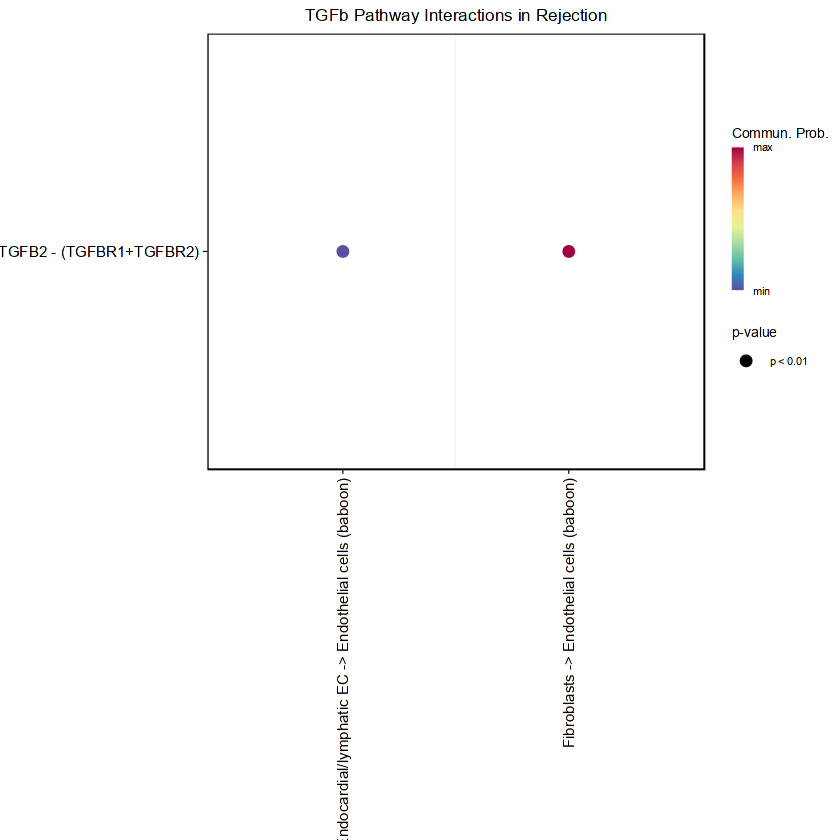

In [25]:
library(CellChat)
library(ggplot2)

# Get all significant ligand-receptor pairs for the TGFb pathway in the Rejection condition
net_rej <- subsetCommunication(cellchat_rej, signaling = "TGFb")

# Create the bubble plot
p_bubble <- netVisual_bubble(
  cellchat_rej,
  sources.use = unique(net_rej$source),
  targets.use = unique(net_rej$target),
  signaling = "TGFb",
  title.name = "TGFb Pathway Interactions in Rejection",
  font.size = 11,
  angle.x = 90
)

# Print and save the plot
print(p_bubble)
ggsave(
  filename = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/TGFb_Rejection_bubble_plot.pdf",
  plot = p_bubble,
  width = 8,
  height = 6,
  dpi = 300,
  useDingbats = FALSE
)
cat("Bubble plot saved at: TGFb_Rejection_bubble_plot.pdf\n")

Bubble plot from CSV data saved.


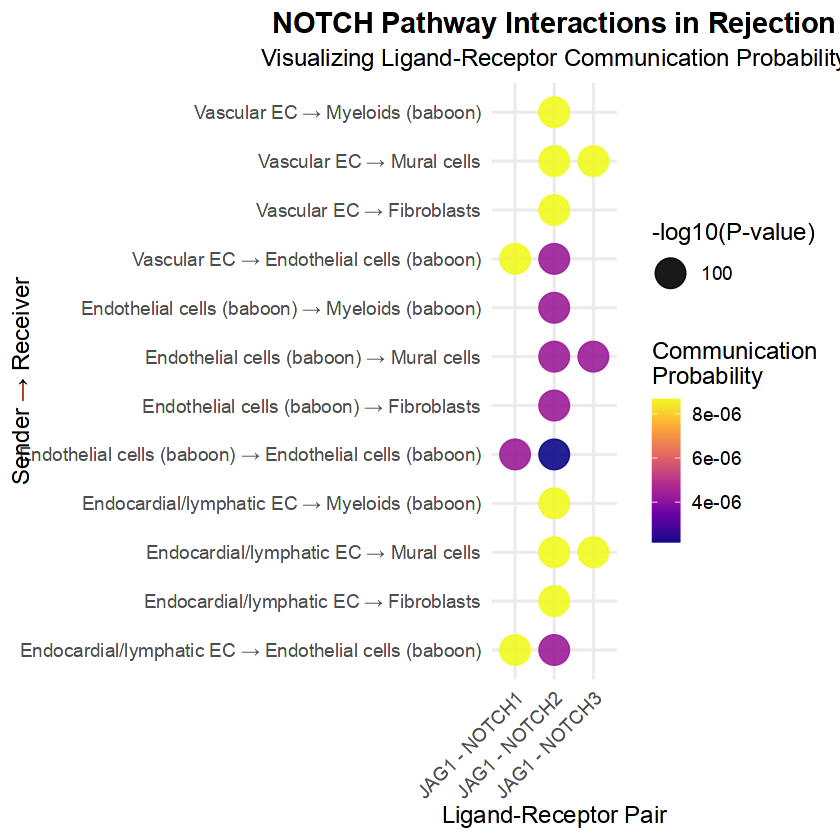

In [56]:
library(dplyr)
library(ggplot2)
library(tidyr)
library(scales)

# Load the data from your CSV file
df_rej <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Standard_CCC_info_table.csv")

# Filter for the TGFb pathway and perform data cleaning and preparation
plot_data <- df_rej %>%
  filter(pathway_name == "NOTCH") %>%
  # Ensure pval and prob are numeric
  mutate(pval = as.numeric(as.character(pval)),
         prob = as.numeric(as.character(prob))) %>%
  # Handle pval = 0 by setting it to a very small number to avoid -Inf
  mutate(pval = ifelse(pval == 0, 1e-100, pval)) %>%
  # Create a combined source-target label for the y-axis
  mutate(source_target = paste(source, "→", target)) %>%
  # Use interaction_name_2 for cleaner ligand-receptor pair labels
  mutate(lr_pair = interaction_name_2) %>%
  # Convert to factors to ensure correct plotting
  mutate(source_target = as.factor(source_target),
         lr_pair = as.factor(lr_pair))

# Create the bubble plot
p_bubble <- ggplot(plot_data, aes(
  x = lr_pair,
  y = source_target,
  size = -log10(pval), # Bubble size based on significance
  color = prob # Color based on communication probability
)) +
  geom_point(alpha = 0.9) +
  scale_size_continuous(range = c(3, 10), name = "-log10(P-value)") +
  scale_color_viridis_c(option = "plasma", name = "Communication\nProbability") +
  labs(
    title = "NOTCH Pathway Interactions in Rejection",
    subtitle = "Visualizing Ligand-Receptor Communication Probability",
    x = "Ligand-Receptor Pair",
    y = "Sender → Receiver"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 11),
    axis.text.y = element_text(size = 11),
    legend.position = "right",
    plot.title = element_text(face = "bold", hjust = 0.5),
    plot.subtitle = element_text(hjust = 0.5)
  )

# Print and save the plot
print(p_bubble)
ggsave(
  filename = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/NOTCH_bubble_plot_from_csv.pdf",
  plot = p_bubble,
  width = 9,
  height = 7,
  dpi = 300,
  useDingbats = FALSE
)
cat("Bubble plot from CSV data saved.\n")

Bubble plot from CSV data saved.


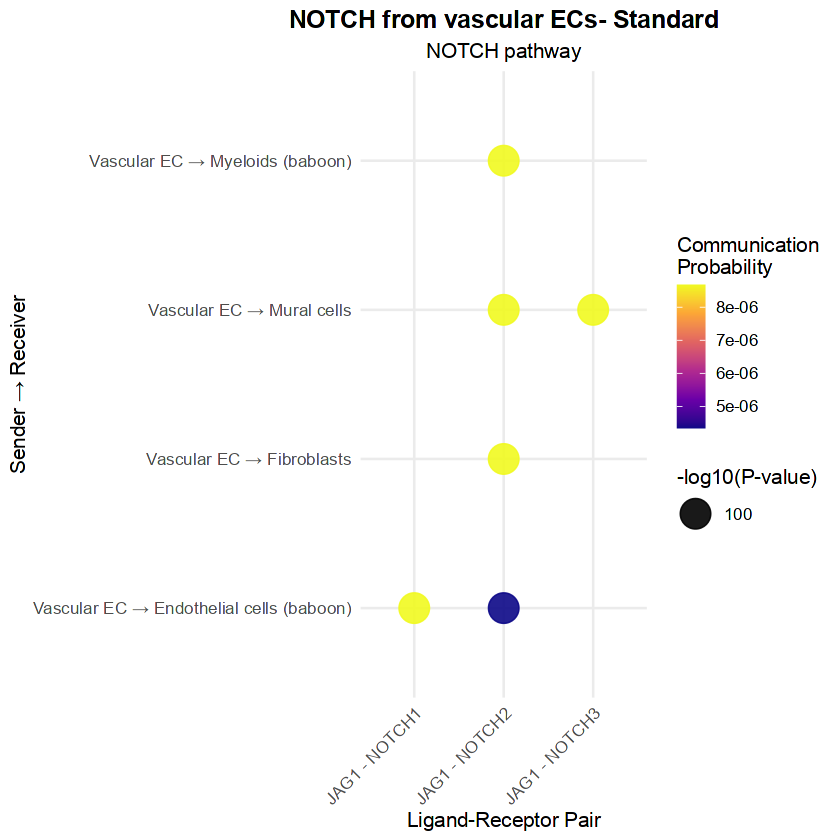

In [67]:
library(dplyr)
library(ggplot2)
library(tidyr)
library(scales)
library(viridis) # Ensure viridis is loaded for scale_color_viridis_c

# Load the data from your CSV file
df_rej <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Standard_CCC_info_table.csv")

# Filter for the NOTCH pathway and specific sender cells
plot_data <- df_rej %>%
  filter(
    pathway_name == "NOTCH",
    source == "Vascular EC" 
      # | source == "Endocardial/lymphatic EC"
  ) %>%
  # Ensure pval and prob are numeric
  mutate(pval = as.numeric(as.character(pval)),
         prob = as.numeric(as.character(prob))) %>%
  # Handle pval = 0 by setting it to a very small number to avoid -Inf
  mutate(pval = ifelse(pval == 0, 1e-100, pval)) %>%
  # Create a combined source-target label for the y-axis
  mutate(source_target = paste(source, "→", target)) %>%
  # Use interaction_name_2 for cleaner ligand-receptor pair labels
  mutate(lr_pair = interaction_name_2) %>%
  # Convert to factors to ensure correct plotting
  mutate(source_target = as.factor(source_target),
         lr_pair = as.factor(lr_pair))

# Create the bubble plot
p_bubble <- ggplot(plot_data, aes(
  x = lr_pair,
  y = source_target,
  size = -log10(pval), # Bubble size based on significance
  color = prob # Color based on communication probability
)) +
  geom_point(alpha = 0.9) +
  scale_size_continuous(range = c(3, 10), name = "-log10(P-value)") +
  scale_color_viridis_c(option = "plasma", name = "Communication\nProbability") +
  labs(
    title = "NOTCH from vascular ECs- Standard",
    subtitle = "NOTCH pathway",
    x = "Ligand-Receptor Pair",
    y = "Sender → Receiver"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 10),
    axis.text.y = element_text(size = 10),
    legend.position = "right",
    plot.title = element_text(face = "bold", hjust = 0.5),
    plot.subtitle = element_text(hjust = 0.5)
  )

# Print and save the plot
print(p_bubble)
ggsave(
  filename = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/NOTCH_bubble_plot_from_csv.pdf",
  plot = p_bubble,
  width = 7,
  height = 4,
  dpi = 300,
  useDingbats = FALSE
)
cat("Bubble plot from CSV data saved.\n")

In [29]:
library(dplyr)
library(tidyr)
library(circlize)
library(viridis)

# Load the data from your CSV file
df_rej <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Rejection_info_table.csv")

# Filter for the specific pathway (VISFATIN in this case)
tgfb_data <- df_rej %>%
  filter(pathway_name == "TGFb")

# Define custom colors (Crucial: This list must contain ALL cell types you want to visualize)
custom_colors <- c(
  "Lymphoids (baboon)" = "#FFA500", 
  "Mast cells (baboons)" = "#FFC0CB", 
  "Mural cells" = "#C8A2C8", 
  "Myeloids (baboon)" = "#A52A2A", 
  "Neuronal cells" = "#87CEFA", 
  "Resident Immune" = "#000080", 
  "Vascular EC" = "#006400", 
  "CM" = "#FA8072", 
  "Fibroblasts" = "#A020F0",
  "Endothelial cells (baboon)" = "#4CAF50",
  "Endocardial/lymphatic EC" = "#1F78B4"
)

# --- THE CRITICAL MODIFICATION ---
# Simply set the color mapping to the full custom_colors vector.
# This ensures that ALL defined cell types are available for plotting.
cell_type_color_mapping <- custom_colors 

# Generate the chord diagram
pdf(file = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/FANCY_circos/TGFb_circos_Rejection.pdf",
    width = 7, height = 7)

circos.clear()
circos.par(start.degree = 90, gap.degree = 15)

chordDiagram(
  x = tgfb_data %>% select(source, target, prob),
  grid.col = cell_type_color_mapping, # Uses the full color list
  directional = 1,
  direction.type = c("diffHeight", "arrows"),
  link.arr.type = "big.arrow",
  link.arr.length = 0.15,
  link.sort = TRUE,
  link.border = "grey"
)

circos.track(track.index = 1, ylim = c(0, 1), panel.fun = function(x, y) {
  circos.text(CELL_META$xcenter, CELL_META$ylim[1] + 1.5, CELL_META$sector.index,
              facing = "clockwise", niceFacing = TRUE, adj = c(0, 0.5), cex = 1.0)
}, bg.border = NA)

title("TGFb Signaling Interactions in Rejection Condition")

dev.off()
cat("Publication-ready chord diagram for TGFb (all cell types) saved.\n")

Note: 1 point is out of plotting region in sector
'Endocardial/lymphatic EC', track '1'.

Note: 1 point is out of plotting region in sector
'Endocardial/lymphatic EC', track '1'.

Note: 1 point is out of plotting region in sector 'Fibroblasts', track
'1'.

Note: 1 point is out of plotting region in sector 'Fibroblasts', track
'1'.

Note: 1 point is out of plotting region in sector 'Endothelial cells
(baboon)', track '1'.

Note: 1 point is out of plotting region in sector 'Endothelial cells
(baboon)', track '1'.



png 
  2

Publication-ready chord diagram for TGFb (all cell types) saved.


In [ ]:
library(dplyr)
library(ggplot2)

# Combine both groups and calculate difference
top_diff <- bind_rows(
  df_std %>% mutate(Condition = "Standard Protocol"),
  df_rej %>% mutate(Condition = "Rejection")
) %>%
  filter(pathway_name == "FN1") %>%  # or any pathway
  group_by(ligand, receptor, source, target) %>%
  summarize(
    prob_std = sum(prob[Condition == "Standard Protocol"], na.rm = TRUE),
    prob_rej = sum(prob[Condition == "Rejection"], na.rm = TRUE)
  ) %>%
  mutate(diff = prob_rej - prob_std) %>%
  arrange(desc(abs(diff))) %>%
  head(20)

# Create the plot
p <- ggplot(top_diff, aes(
  x = paste(source, "→", target), 
  y = paste(ligand, receptor, sep = "-"), 
  size = abs(diff), 
  color = diff)) +
  geom_point() +
  scale_color_gradient2(low = "blue", high = "red", mid = "grey95", midpoint = 0) +
  labs(
    title = "Top 20 differential FN1 ligand–Receptor pairs (Sender: Fibroblasts)",
    x = "Sender → Receiver", y = "Ligand–Receptor Pair", size = "ΔProbability", color = "ΔProbability"
  ) +
  theme_minimal(base_size = 15) +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.001, hjust = 1, size = 11),
    axis.text.y = element_text(size = 11)
  )

# Save as high-res PDF
ggsave(
  filename = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/special_sankey_Fibroblasts/Top_20_FN1_LR_diff_bubble.pdf",
  plot = p,
  width = 9, height = 7, dpi = 300, useDingbats = FALSE
)

print(p)
cat("PDF saved at: Top20_FN1_LR_diff_bubble.pdf\n")


In [ ]:
# For the rejection group, showing top ligand-receptor pairs:
netVisual_bubble(cellchat_rej, 
  sources.use = c("Fibroblasts"), 
  targets.use = c("CM", "Endocardial/lymphatic EC"),
  signaling = "COLLAGEN",        # or "FN1", or leave out for all
  remove.isolate = FALSE,
  title.name = "Top Collagen Ligand-Receptor Pairs",
  font.size = 12, angle.x = 90
)


--------------------------------------------------

In [ ]:
# ---- RankNet differential signaling analysis and plot differential circle plots ----

library(CellChat)

# Directory for plots and CSV
output_dir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/cell_type_circle_plots/Resident_Immune"
if (!dir.exists(output_dir)) dir.create(output_dir, recursive = TRUE)

# Set sender of interest
my_sender <- "Resident Immune"    # CHANGE for other cell types

# 1. Run rankNet to get all candidate pathways for this sender
ranknet_frame <- rankNet(
  cellchat_merged,
  mode = "comparison",
  stacked = TRUE,
  do.stat = TRUE,
  cutoff.pvalue = 0.05,
  return.data = TRUE,
  sources.use = my_sender,
  measure = "weight"
)$signaling.contribution

# --- Save as CSV (not table!) ---
csv_out <- file.path(output_dir, "resident_immune_diff_sig_table.csv")
write.csv(ranknet_frame, file = csv_out, row.names = FALSE)
cat("RankNet differential signaling results saved to:", csv_out, "\n")

# Option 1: Use all tested pathways for plotting
all_pathways <- unique(ranknet_frame$name) # or $signaling

for (this_pathway in all_pathways) {
  # Get group-specific aggregate nets for this pathway
  group1 <- tryCatch({
    aggregateNet(cellchat_rej, signaling = this_pathway, remove.isolate = FALSE)
  }, error = function(e) NULL)
  group2 <- tryCatch({
    aggregateNet(cellchat_standard, signaling = this_pathway, remove.isolate = FALSE)
  }, error = function(e) NULL)
  
  # Check if both groups have valid nets
  if (is.null(group1) || is.null(group2)) {
    message(sprintf("Skipping %s: no interaction in one of the groups", this_pathway))
    next
  }
  
  # Merge for diff plotting
  object_list <- list(Rejection = group1, `Standard protocol` = group2)
  cellchat_pathway <- mergeCellChat(object_list, add.names = names(object_list))
  
  # Get maximum edge weight for scaling
  weight.max <- tryCatch({
    getMaxWeight(object_list, slot.name = "netP", attribute = this_pathway)
  }, error = function(e) NULL)
  if (is.null(weight.max)) {
    message(sprintf("Skipping %s: getMaxWeight failed", this_pathway))
    next
  }
  
  # Plot! (tryCatch for robustness)
  g <- tryCatch({
    netVisual_diffInteraction(
      cellchat_pathway,
      weight.scale = TRUE,
      measure = "weight",
      color.edge = c("#6ECFF6", "#FA8072"),  # Sky blue, salmon (Standard, Rejection)
      title.name = sprintf("%s (%s)", this_pathway, my_sender),
      label.edge = FALSE,
      arrow.size = 1.5,
      arrow.width = 2,
      alpha.edge = 0.8,
      margin = 0.4,
      vertex.label.cex = 1.2,
      edge.weight.max = weight.max[1],
      edge.width.max = 10,
      sources.use = my_sender
    )
  }, error = function(e) {
    message(sprintf("Skipping %s: plotting failed - %s", this_pathway, e$message))
    return(NULL)
  })
  
  if (!is.null(g)) {
    # Clean the pathway name for filename
    safe_name <- gsub("[/\\\\ ]", "_", this_pathway)
    pdf(file = file.path(output_dir, sprintf("%s_differential_%s.pdf", safe_name, gsub(" ", "", my_sender))), width = 7, height = 7)
    print(g)
    dev.off()
  }
}

cat("All pathway-specific differential circle plots are in:", output_dir, "\n")


In [ ]:
library(CellChat)

# ---- Set up master output dir ----
main_output_dir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/cell_type_DIFF_chord_plots"
if (!dir.exists(main_output_dir)) dir.create(main_output_dir, recursive = TRUE)

# ---- Get all sender types (union of both objects) ----
all_senders <- union(levels(cellchat_rej@idents), levels(cellchat_standard@idents))

# ---- Safe filename function ----
safe_filename <- function(x) {
  gsub("[/\\\\ ]", "_", x)
}

for (my_sender in all_senders) {
  cat("Processing sender:", my_sender, "\n")
  
  # Subfolder for this sender
  sender_dir <- file.path(main_output_dir, safe_filename(my_sender))
  if (!dir.exists(sender_dir)) dir.create(sender_dir, recursive = TRUE)
  
  # 1. Run rankNet for this sender
  ranknet_frame <- rankNet(
    cellchat_merged,
    mode = "comparison",
    stacked = TRUE,
    do.stat = TRUE,
    cutoff.pvalue = 0.05,
    return.data = TRUE,
    sources.use = my_sender,
    measure = "weight"
  )$signaling.contribution
  
  # Save CSV with diff signaling pathways for this sender
  csv_out <- file.path(sender_dir, paste0(safe_filename(my_sender), "_diff_sig_table.csv"))
  write.csv(ranknet_frame, file = csv_out, row.names = FALSE)
  
  # Option 1: Use all tested pathways for plotting
  all_pathways <- unique(ranknet_frame$name)
  
  for (this_pathway in all_pathways) {
    # Get group-specific aggregate nets for this pathway
    group1 <- tryCatch({
      aggregateNet(cellchat_rej, signaling = this_pathway, remove.isolate = FALSE)
    }, error = function(e) NULL)
    group2 <- tryCatch({
      aggregateNet(cellchat_standard, signaling = this_pathway, remove.isolate = FALSE)
    }, error = function(e) NULL)
    
    # Skip if not present in both
    if (is.null(group1) || is.null(group2)) {
      message(sprintf("Skipping %s for %s: no interaction in one of the groups", this_pathway, my_sender))
      next
    }
    
    # Merge for diff plotting
    object_list <- list(Rejection = group1, `Standard protocol` = group2)
    cellchat_pathway <- mergeCellChat(object_list, add.names = names(object_list))
    
    # Get maximum edge weight for scaling
    weight.max <- tryCatch({
      getMaxWeight(object_list, slot.name = "netP", attribute = this_pathway)
    }, error = function(e) NULL)
    if (is.null(weight.max)) {
      message(sprintf("Skipping %s for %s: getMaxWeight failed", this_pathway, my_sender))
      next
    }
    
    # Plot
    g <- tryCatch({
      netVisual_diffInteraction(
        cellchat_pathway,
        weight.scale = TRUE,
        measure = "weight",
        color.edge = c("#6ECFF6", "#FA8072"),  # Sky blue, salmon
        title.name = sprintf("%s (%s)", this_pathway, my_sender),
        label.edge = FALSE,
        arrow.size = 1.5,
        arrow.width = 2,
        alpha.edge = 0.8,
        margin = 0.4,
        vertex.label.cex = 1.2,
        edge.weight.max = weight.max[1],
        edge.width.max = 10,
        sources.use = my_sender
      )
    }, error = function(e) {
      message(sprintf("Skipping %s for %s: plotting failed - %s", this_pathway, my_sender, e$message))
      return(NULL)
    })
    
    if (!is.null(g)) {
      safe_path <- safe_filename(this_pathway)
      pdf(file = file.path(sender_dir, sprintf("%s_differential_%s.pdf", safe_path, safe_filename(my_sender))), width = 7, height = 7)
      print(g)
      dev.off()
    }
  }
  
  cat("Finished sender:", my_sender, "\n")
}
cat("All sender-specific differential plots and CSVs saved under:", main_output_dir, "\n")


In [ ]:
dev.off()

library(pheatmap)
library(dplyr)
library(tidyr)

# Load your Rejection info table
df_rej <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Rejection_info_table.csv", stringsAsFactors = FALSE)

# Build sender–target count matrix for p<0.05
heat <- df_rej %>%
  filter(pval < 0.05) %>%
  group_by(source, target) %>%
  summarize(count = n(), .groups = "drop") %>%
  pivot_wider(names_from = target, values_from = count, values_fill = 0)

mat <- as.matrix(heat[,-1])
rownames(mat) <- heat$source

# Draw heatmap (clustered)
pheatmap(mat, cluster_rows = TRUE, cluster_cols = TRUE, 
         main = "Sender-Target Communication Counts (Rejection)")

pdf("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/heatmaps/SenderTargetHeatmap_Rejection.pdf", width=10, height=8)
pheatmap(mat, cluster_rows = TRUE, cluster_cols = TRUE, 
         main = "Sender-Target Communication Counts (Rejection)")
dev.off()



# -----------------------------------------------


# Load your Rejection info table
df_rej <- read.csv("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Standard_CCC_info_table.csv", stringsAsFactors = FALSE)

# Build sender–target count matrix for p<0.05
heat <- df_rej %>%
  filter(pval < 0.05) %>%
  group_by(source, target) %>%
  summarize(count = n(), .groups = "drop") %>%
  pivot_wider(names_from = target, values_from = count, values_fill = 0)

mat <- as.matrix(heat[,-1])
rownames(mat) <- heat$source

# Draw heatmap (clustered)
pheatmap(mat, cluster_rows = TRUE, cluster_cols = TRUE, 
         main = "Sender-Target Communication Counts (Rejection)")

pdf("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/heatmaps/SenderTargetHeatmap_Standard.pdf", width=10, height=8)
pheatmap(mat, cluster_rows = TRUE, cluster_cols = TRUE, 
         main = "Sender-Target Communication Counts (Rejection)")
dev.off()


In [ ]:
# --------------------------------------------------------------------------
# 1. Load Necessary Libraries
# --------------------------------------------------------------------------
library(circlize)
library(dplyr)
library(readr)

# --------------------------------------------------------------------------
# 2. Define File Paths and Output Location
# --------------------------------------------------------------------------
FP_REJ <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Rejection_info_table.csv"
FP_STANDARD <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/csv_results/cellchat_Standard_CCC_info_table.csv"
output_dir <- "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/Diff_CC/Rej_vs_standard/fig_results/Specific_Pathway_Plots"
if (!dir.exists(output_dir)) dir.create(output_dir, recursive = TRUE)

# --------------------------------------------------------------------------
# 3. Function to Generate a Single Chord Diagram
# --------------------------------------------------------------------------
create_chord_diagram <- function(filepath, condition_name, output_dir) {
  # Read the CSV file
  df <- read_csv(filepath)
  
  # Print column names for debugging
  message(paste("Column names in", condition_name, "file:", paste(names(df), collapse = ", ")))
  
  # Check for the required columns before proceeding
  required_cols <- c("source", "target", "prob", "pathway_name")
  if (!all(required_cols %in% names(df))) {
    missing_cols <- required_cols[!required_cols %in% names(df)]
    message(paste("Required columns missing:", paste(missing_cols, collapse = ", ")))
    return(invisible(NULL))
  }
  
  # Filter for the specific pathway and select/rename columns
  plot_df <- df %>%
    filter(pathway_name == "TGFb") %>%
    select(source, target, prob) %>%
    rename(from = source, to = target, value = prob) %>%
    distinct()
  
  if (nrow(plot_df) == 0) {
    message(paste("No TGFb interactions found for", condition_name, ". Skipping plot."))
    return(invisible(NULL))
  }
  
  # Set up the circular layout with unique cell types
  all_cells <- unique(c(as.character(plot_df$from), as.character(plot_df$to)))
  chord_colors <- structure(
    rep(c("#1f77b4", "#fa8072"), length.out = length(all_cells)),
    names = all_cells
  )
  
  # Generate the plot file path
  output_file <- file.path(output_dir, paste0("TGFb_chord_diagram_", condition_name, ".pdf"))
  pdf(file = output_file, width = 8, height = 8)
  
  # Initialize the chord diagram layout
  circos.clear()
  circos.par(
    start.degree = 90,
    gap.degree = 10,
    track.margin = c(-0.1, 0.1),
    canvas.xlim = c(-1.1, 1.1),
    canvas.ylim = c(-1.1, 1.1)
  )
  
  # Plot the chord diagram
  chordDiagram(
    plot_df,
    grid.col = chord_colors,
    annotationTrack = "grid",
    transparency = 0.4,
    preAllocateTracks = list(
      track.height = 0.1,
      track.margin = c(0, 0.05)
    )
  )
  
  # Add sector labels
  circos.track(
    track.index = 1,
    panel.fun = function(x, y) {
      circos.text(
        CELL_META$xcenter,
        CELL_META$ylim[1],
        CELL_META$sector.index,
        facing = "clockwise",
        niceFacing = TRUE,
        adj = c(0, 0.5),
        cex = 1.0
      )
    },
    bg.border = NA
  )
  
  # Add title
  title(paste("TGFb Pathway in", condition_name), cex.main = 1.5, font.main = 2, line = -2)
  
  # Close the PDF device
  dev.off()
  
  message(paste("Chord Diagram saved to:", output_file))
}

# --------------------------------------------------------------------------
# 4. Execute the function for each condition
# --------------------------------------------------------------------------
create_chord_diagram(FP_REJ, "Rejection", output_dir)
create_chord_diagram(FP_STANDARD, "Standard_protocol", output_dir)